In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# import seaborn as sns
from pathlib import Path

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify, SDS_transects
from osgeo import gdal
gdal.UseExceptions()

from indices import *
from thresholding import *
import wv_utils as wv
import wv_eval
import wv_eval_plotting as wvep
import modified_coastsat
import metrics as m
import local_sl_extraction as lse
import spectral_unmixing as su

# paths
base_dir = "C:\\Users\\avanever\\Documents\\Imagery Datasets\\WV3 SWIR\\W075_N10\\20200104T15431"
swir_fn = os.path.join(base_dir, "20JAN04154316-A3DS-015384188020_01_P001.TIF")
ms_fn = os.path.join(base_dir, "20JAN04154317-M3DS-015384188010_01_P001.TIF")
pan_fn = os.path.join(base_dir, "20JAN04154317-P3DS-015384188010_01_P001.TIF")
ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")

In [2]:
# both transects and shoreline are in EPSG32618 - no conversions necessary

# load low res sim image
# sim_fn = wv.get_sim_tif_name("naive_res_10", base_dir)
sim_fn = wv.get_gs_tif_name("gs_deg_10_S2.tif", base_dir)
sim = gdal.Open(sim_fn, gdal.GA_ReadOnly)
georef = sim.GetGeoTransform()
image_epsg = 32618

sim_bands = wv.load_sim_tif(sim_fn)
im_rgb = sim_bands[:,:,[2, 1, 0]]

# load transects
transect_fn = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\transects\colombia_transects.geojson")
transects = np.array(list(SDS_tools.transects_from_geojson(transect_fn).values()))
print(f"{transects.shape = }")

# load reference shoreline
ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")
ref_sl_list = wv.load_ref_sl(ref_sl_path)
ref_sl_pxl_list = wv.ref_sl_to_pxl(ref_sl_list, georef)
ref_sl_points = wv.shoreline_to_points(ref_sl_list, delta=0.5)
sl_buffer = wv.create_shoreline_buffer(sim_bands.shape[:-1], ref_sl_pxl_list, 10)
print(f"{ref_sl_points.shape = }")

# initialize empty cloud mask
im_nodata = np.full(sim_bands.shape[:-1], False)
cloud_mask = np.full(sim_bands.shape[:-1], False)

# convert transects and reference shoreline to pixel space
transects_0_pxl = SDS_tools.convert_world2pix(transects[:,0,:], georef)
transects_1_pxl = SDS_tools.convert_world2pix(transects[:,1,:], georef)
transects_pix = np.swapaxes(np.stack([transects_0_pxl, transects_1_pxl]), 0, 1)
ref_sl_points_pxl = SDS_tools.convert_world2pix(ref_sl_points, georef)

# crop shoreline and transects to image (borders changes with kernel width)
mask = (ref_sl_points_pxl[:,0] > 0) & (ref_sl_points_pxl[:,0] < sim_bands.shape[1])
mask &= (ref_sl_points_pxl[:,1] > 0) & (ref_sl_points_pxl[:,1] < sim_bands.shape[0])
ref_sl_points_pxl = ref_sl_points_pxl[mask]
ref_sl_points = ref_sl_points[mask]

mask = (transects_pix[:,:,0] > 0) & (transects_pix[:,:,0] < sim_bands.shape[1])
mask &= (transects_pix[:,:,1] > 0) & (transects_pix[:,:,1] < sim_bands.shape[0])
mask = mask[:,0] | mask[:,1]
transects_pix = transects_pix[mask]
transects = transects[mask]

# data/settings dictionaries
sds_settings = {
    'output_epsg': image_epsg,
    'max_dist_ref': 400,
    'min_length_sl': 150, # 500
    'dist_clouds': 30,
}

collider_settings = dict(
    past_dist = 10,
    along_dist = 25,
    min_chainage = -10
)

sds_data = dict(
    cloud_mask=cloud_mask,
    sl_buffer=sl_buffer,
    im_nodata=im_nodata,
    georef=georef,
    image_epsg=image_epsg,
    sds_settings=sds_settings
)

86 transects have been loaded 
coordinates are in epsg:4326
transects.shape = (86, 2, 2)
ref_sl_points.shape = (22900, 2)


In [3]:
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019,
    tct_wetness,
    ddwi,
    ensemble1,
    ensemble2,
]
threshold_functions = [
    otsu,
    local_min_otsu
]
ensemble_idx_funcs = index_functions[:-2] # all but the ensemble indices

## Bests for Shoreline Metric (nearest point) and Transect Metric (median distance)

Best method changes so frequently picking a "best" method is very ambiguous (beyond looking at summary metrics)

Some areas are not extracted well by any methods (around clouds, certain edges)

In [4]:
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

sl_values = np.nanmin(shoreline_metric, axis=0)
best_per_point_idx = np.nanargmin(shoreline_metric, axis=0)

best_per_transect_idx = np.nanargmin(np.abs(transect_metric), axis=0)
t_idx = [i for i in range(transect_metric.shape[1])]
t_values = transect_metric[best_per_transect_idx, t_idx]

30it [00:12,  2.41it/s]


In [5]:
wv_eval.print_metrics(entries, sort_variable="sl_mean")
print("\n")
wv_eval.print_metrics(entries, sort_variable="t_mae")
print("\n")
wv_eval.print_metrics(entries, sort_variable="sl_n_outliers")
print("\n")
wv_eval.print_metrics(entries, sort_variable="t_mean")

                                    sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
ensemble2__otsu:                    4.641        7.551        12.317       1218           0.814        3.515        2.415       
ensemble1__otsu:                    4.791        10.327       19.375       1845           0.727        4.999        3.204       
andwi__otsu:                        5.079        10.765       19.466       1979           1.398        3.919        2.986       
ewi__otsu:                          5.151        10.682       18.895       2001           1.254        3.149        2.473       
nwi__otsu:                          5.523        20.874       47.965       2706           1.996        3.022        2.857       
tct_wetness__local_min_otsu:        5.837        11.081       18.681       2024           2.097        3.515        3.185       
ndwi__otsu:                         6.025        11.520       19.079       2051           -0.075 

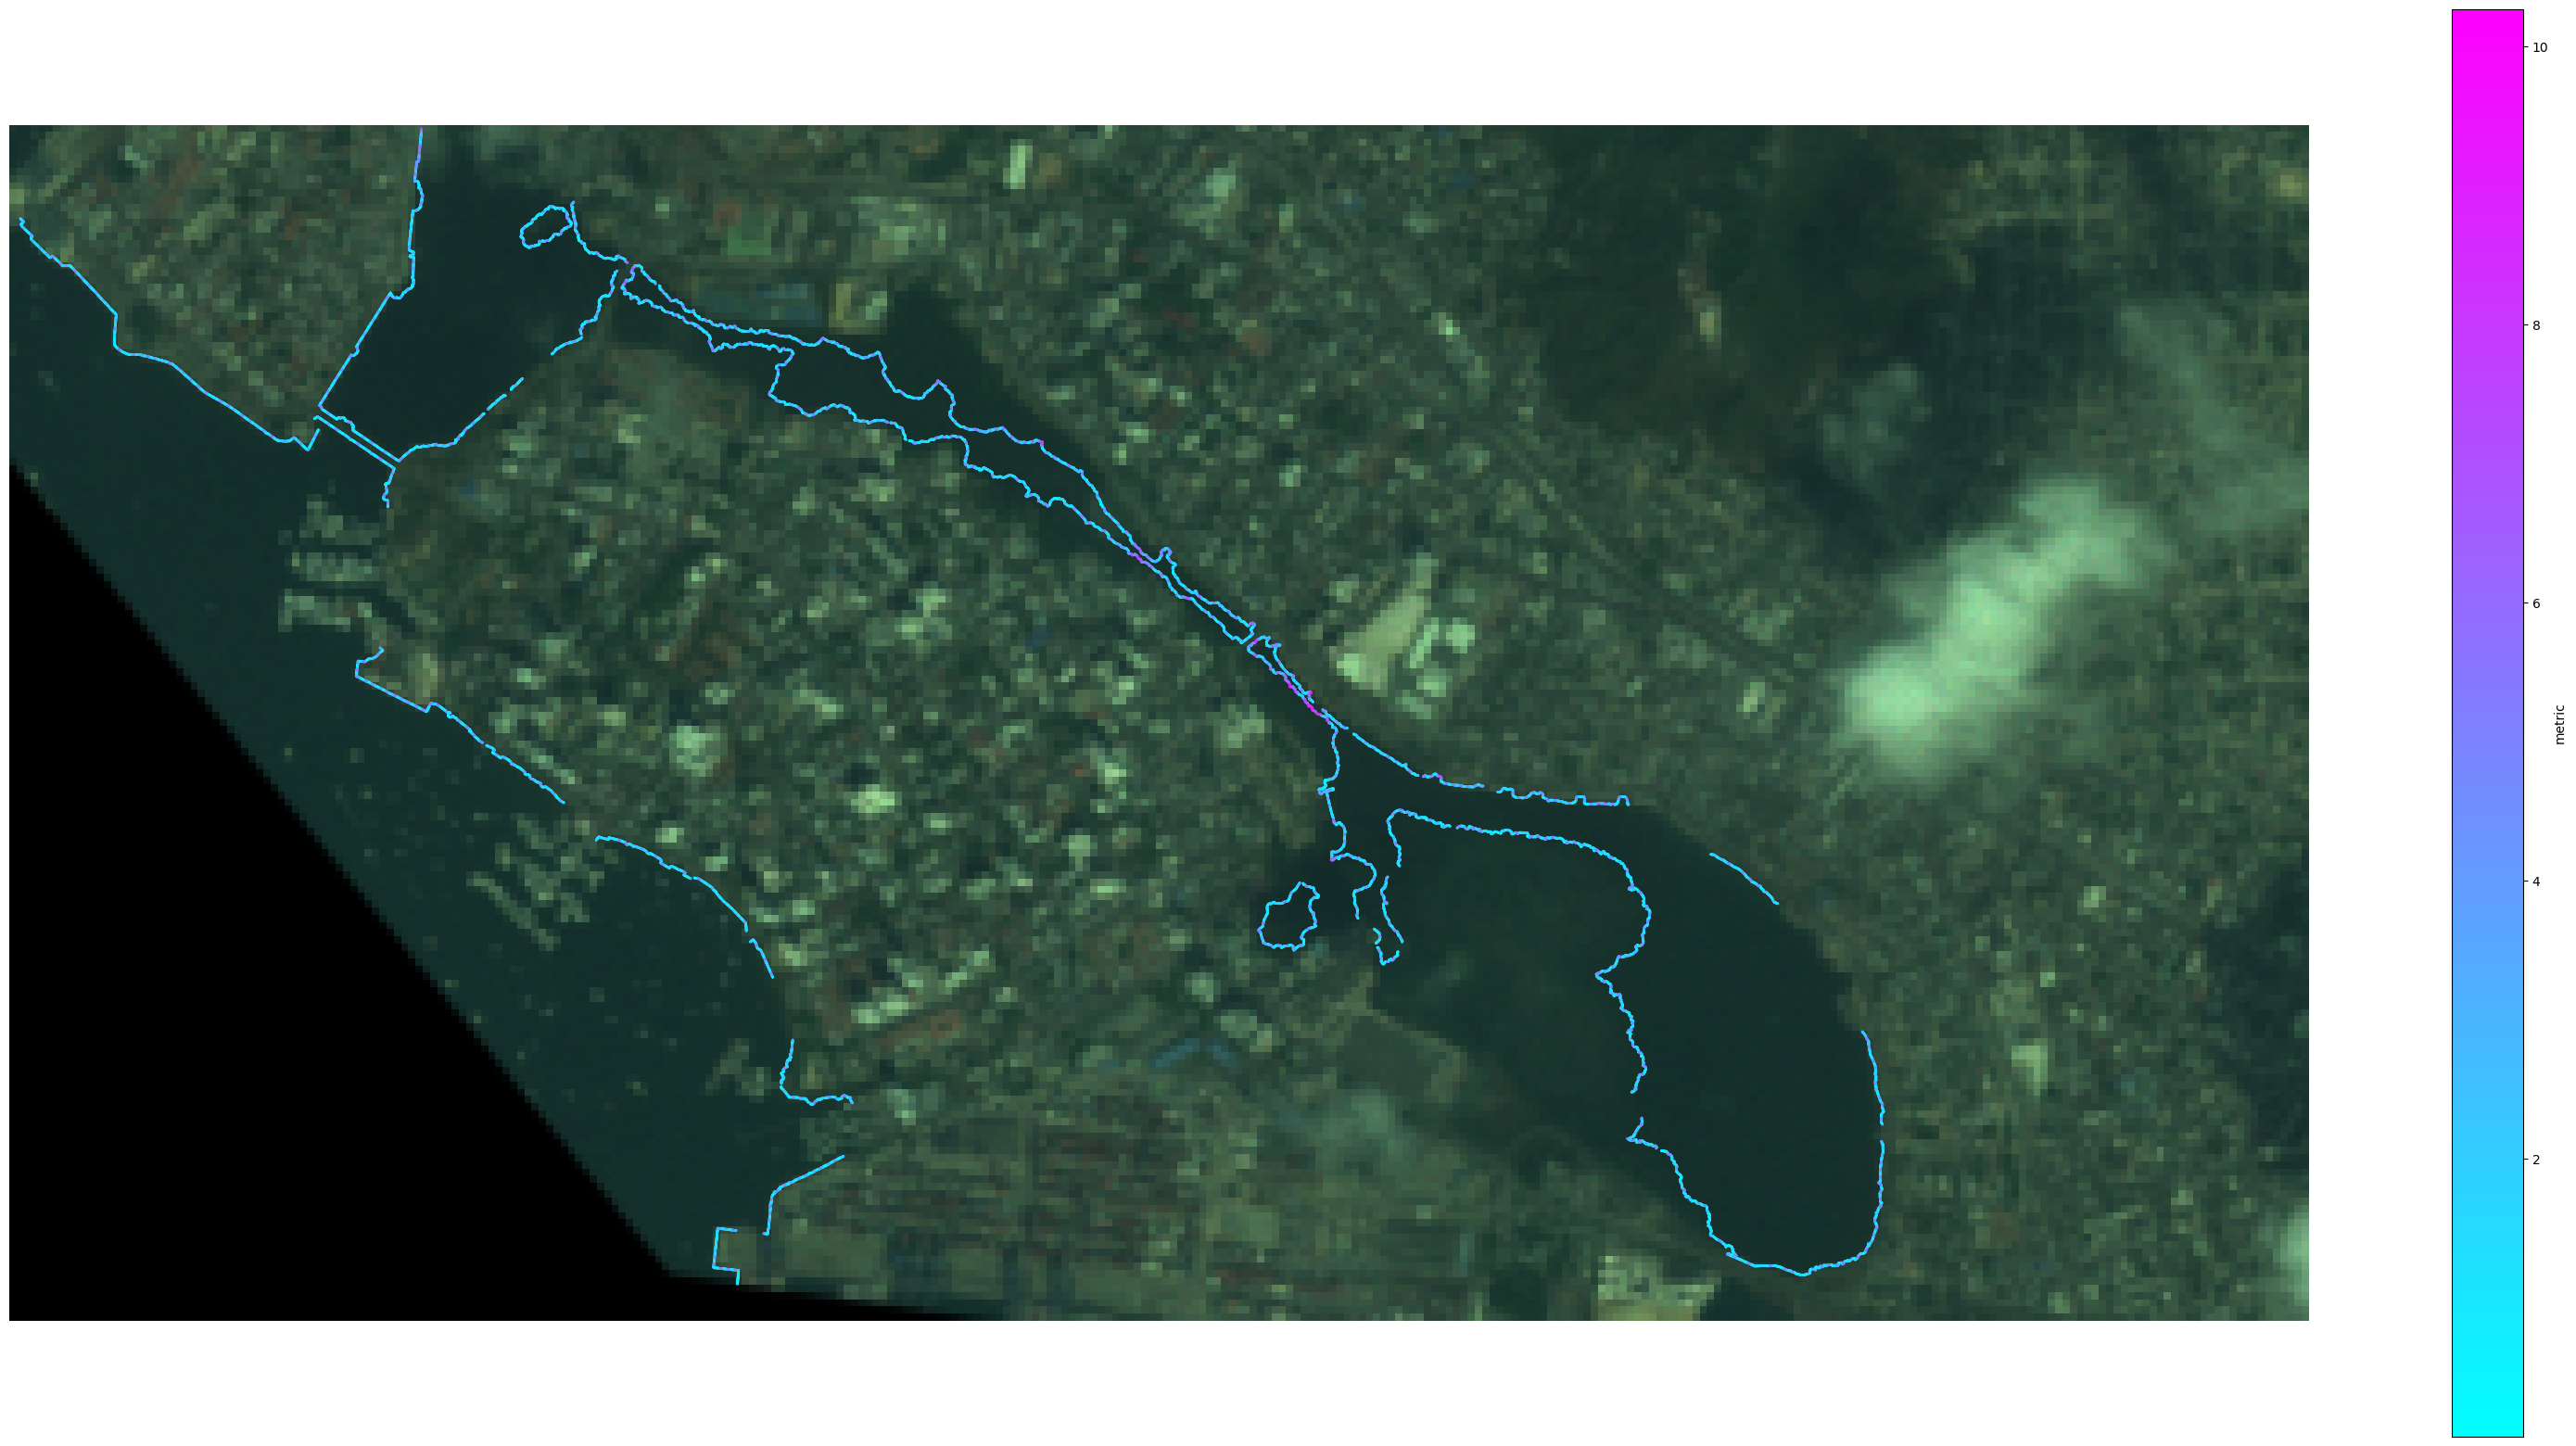

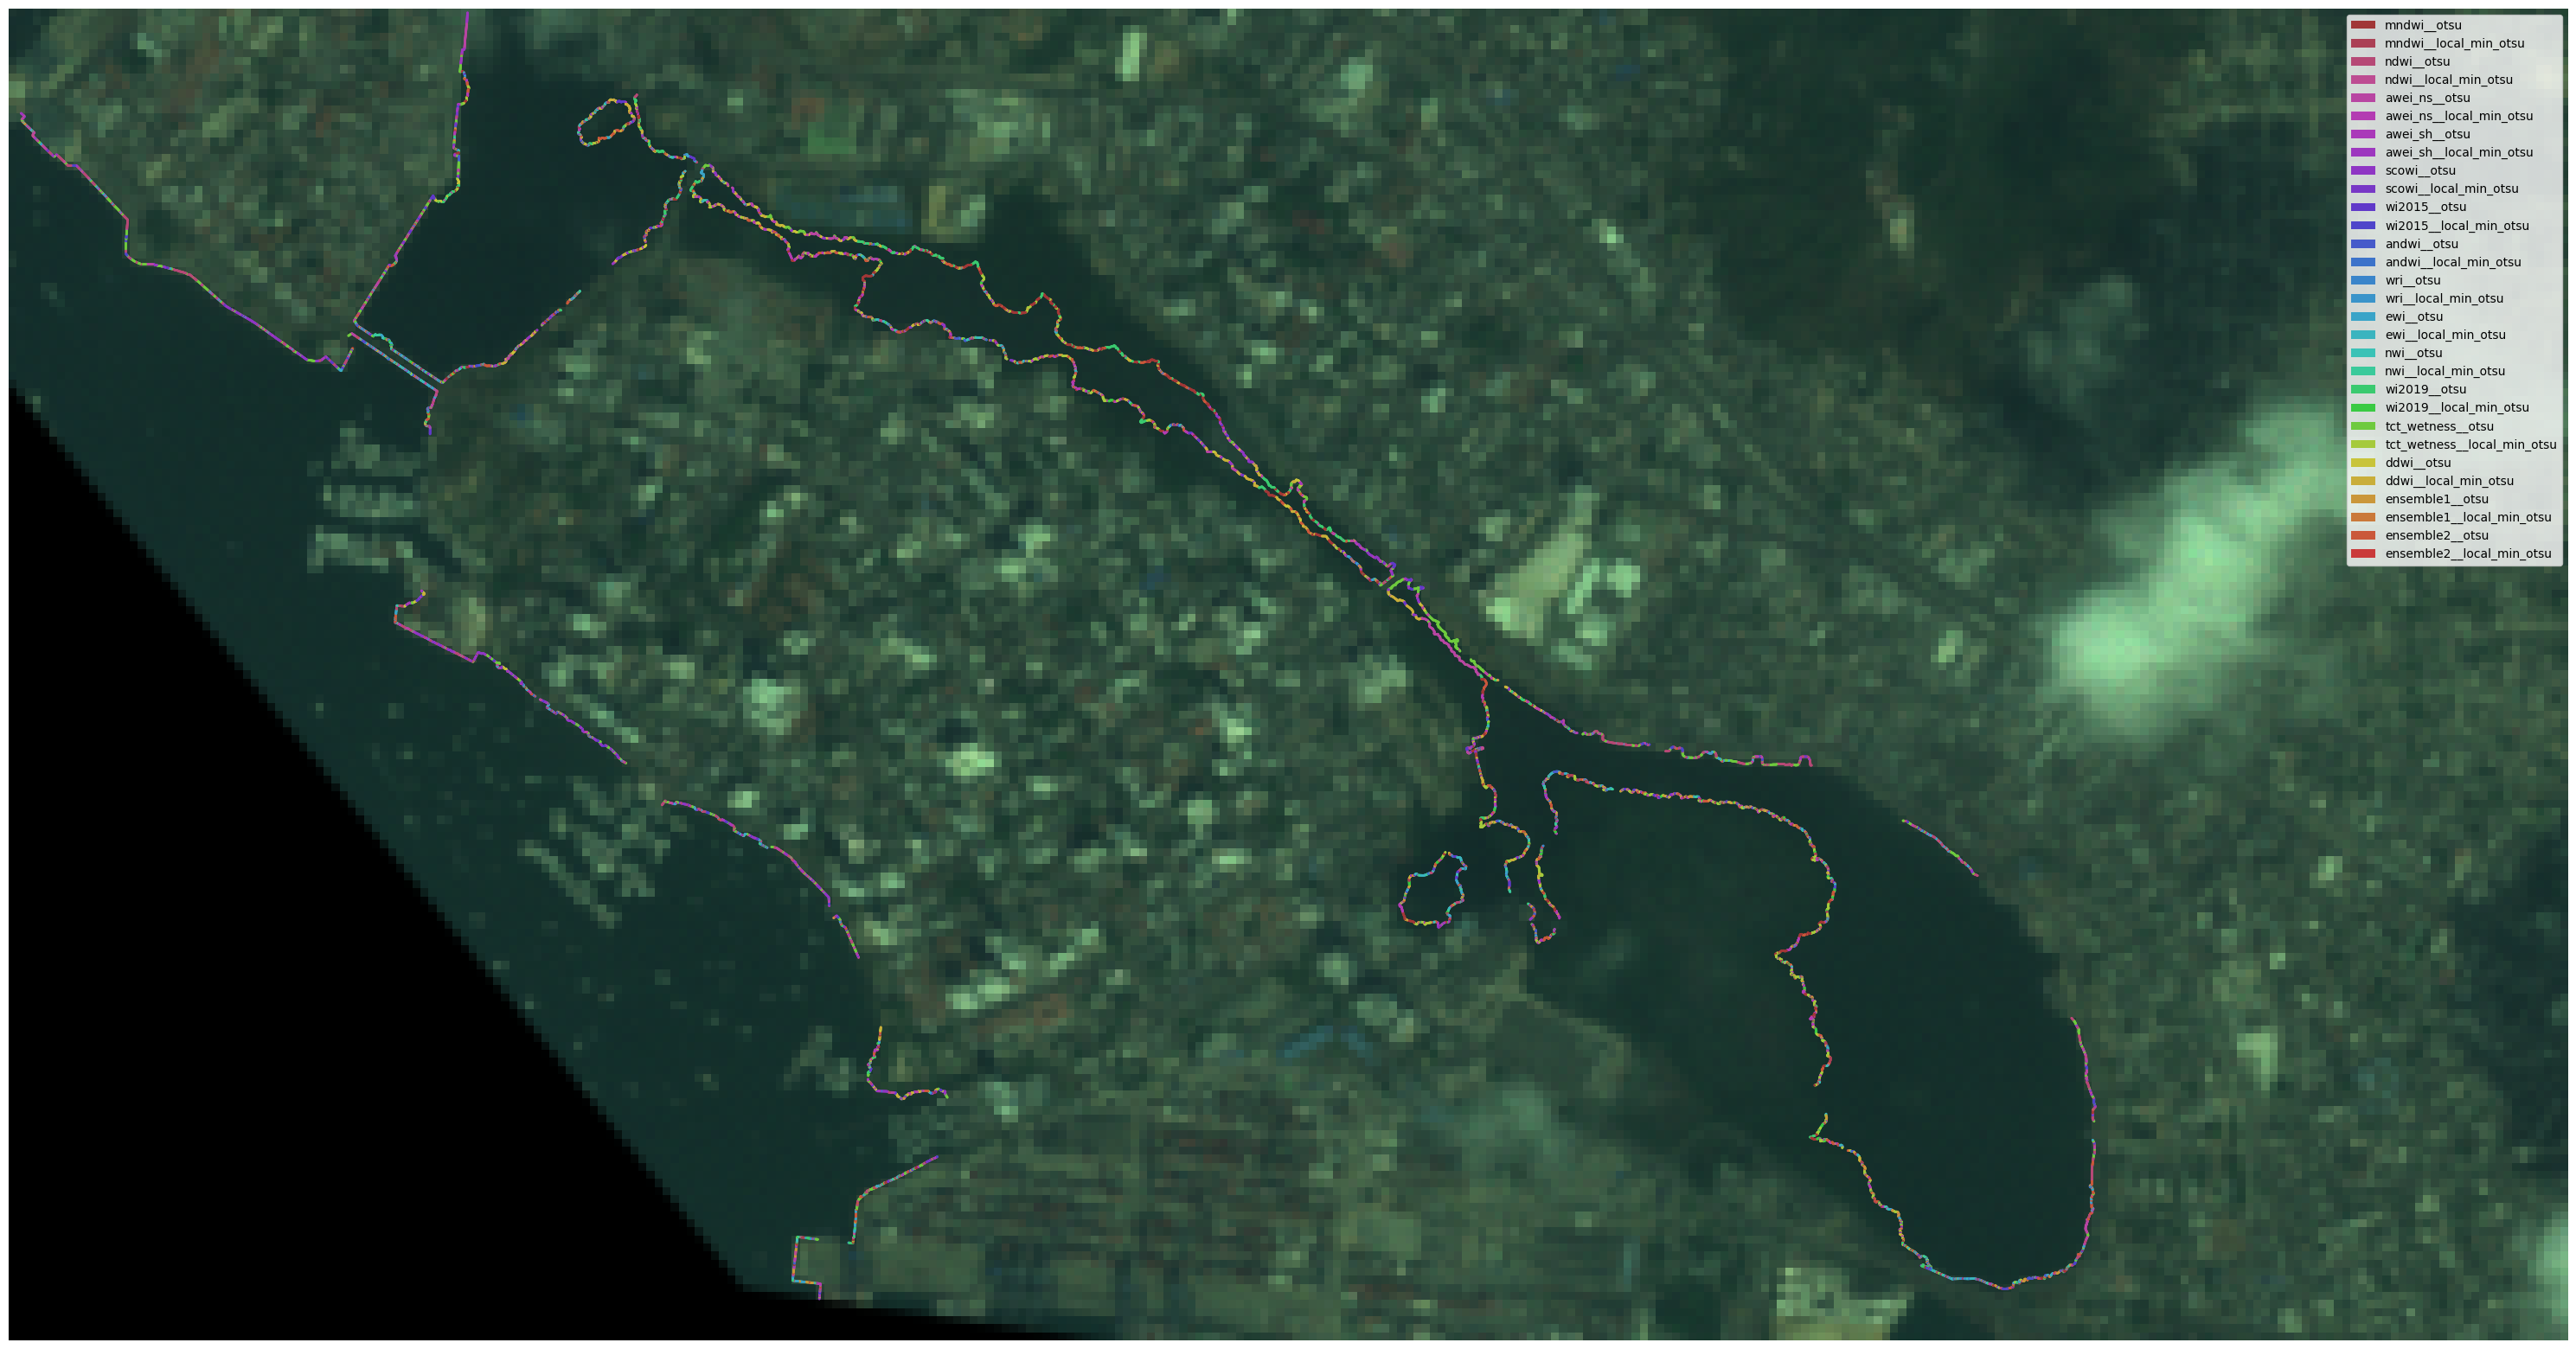

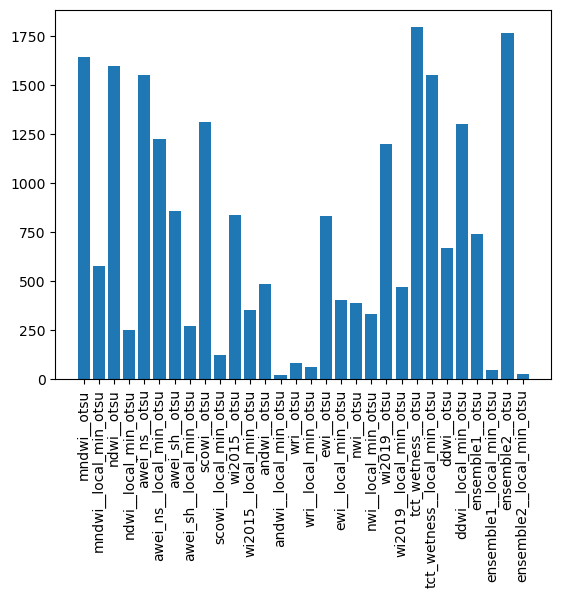

In [69]:
fig = wvep.plot_best_score_per_point(sl_values, ref_sl_points_pxl, im_rgb)
fig = wvep.plot_best_method_per_point(best_per_point_idx, methods, ref_sl_points_pxl, im_rgb)
fig = wvep.plot_best_method_counts(best_per_point_idx, methods)

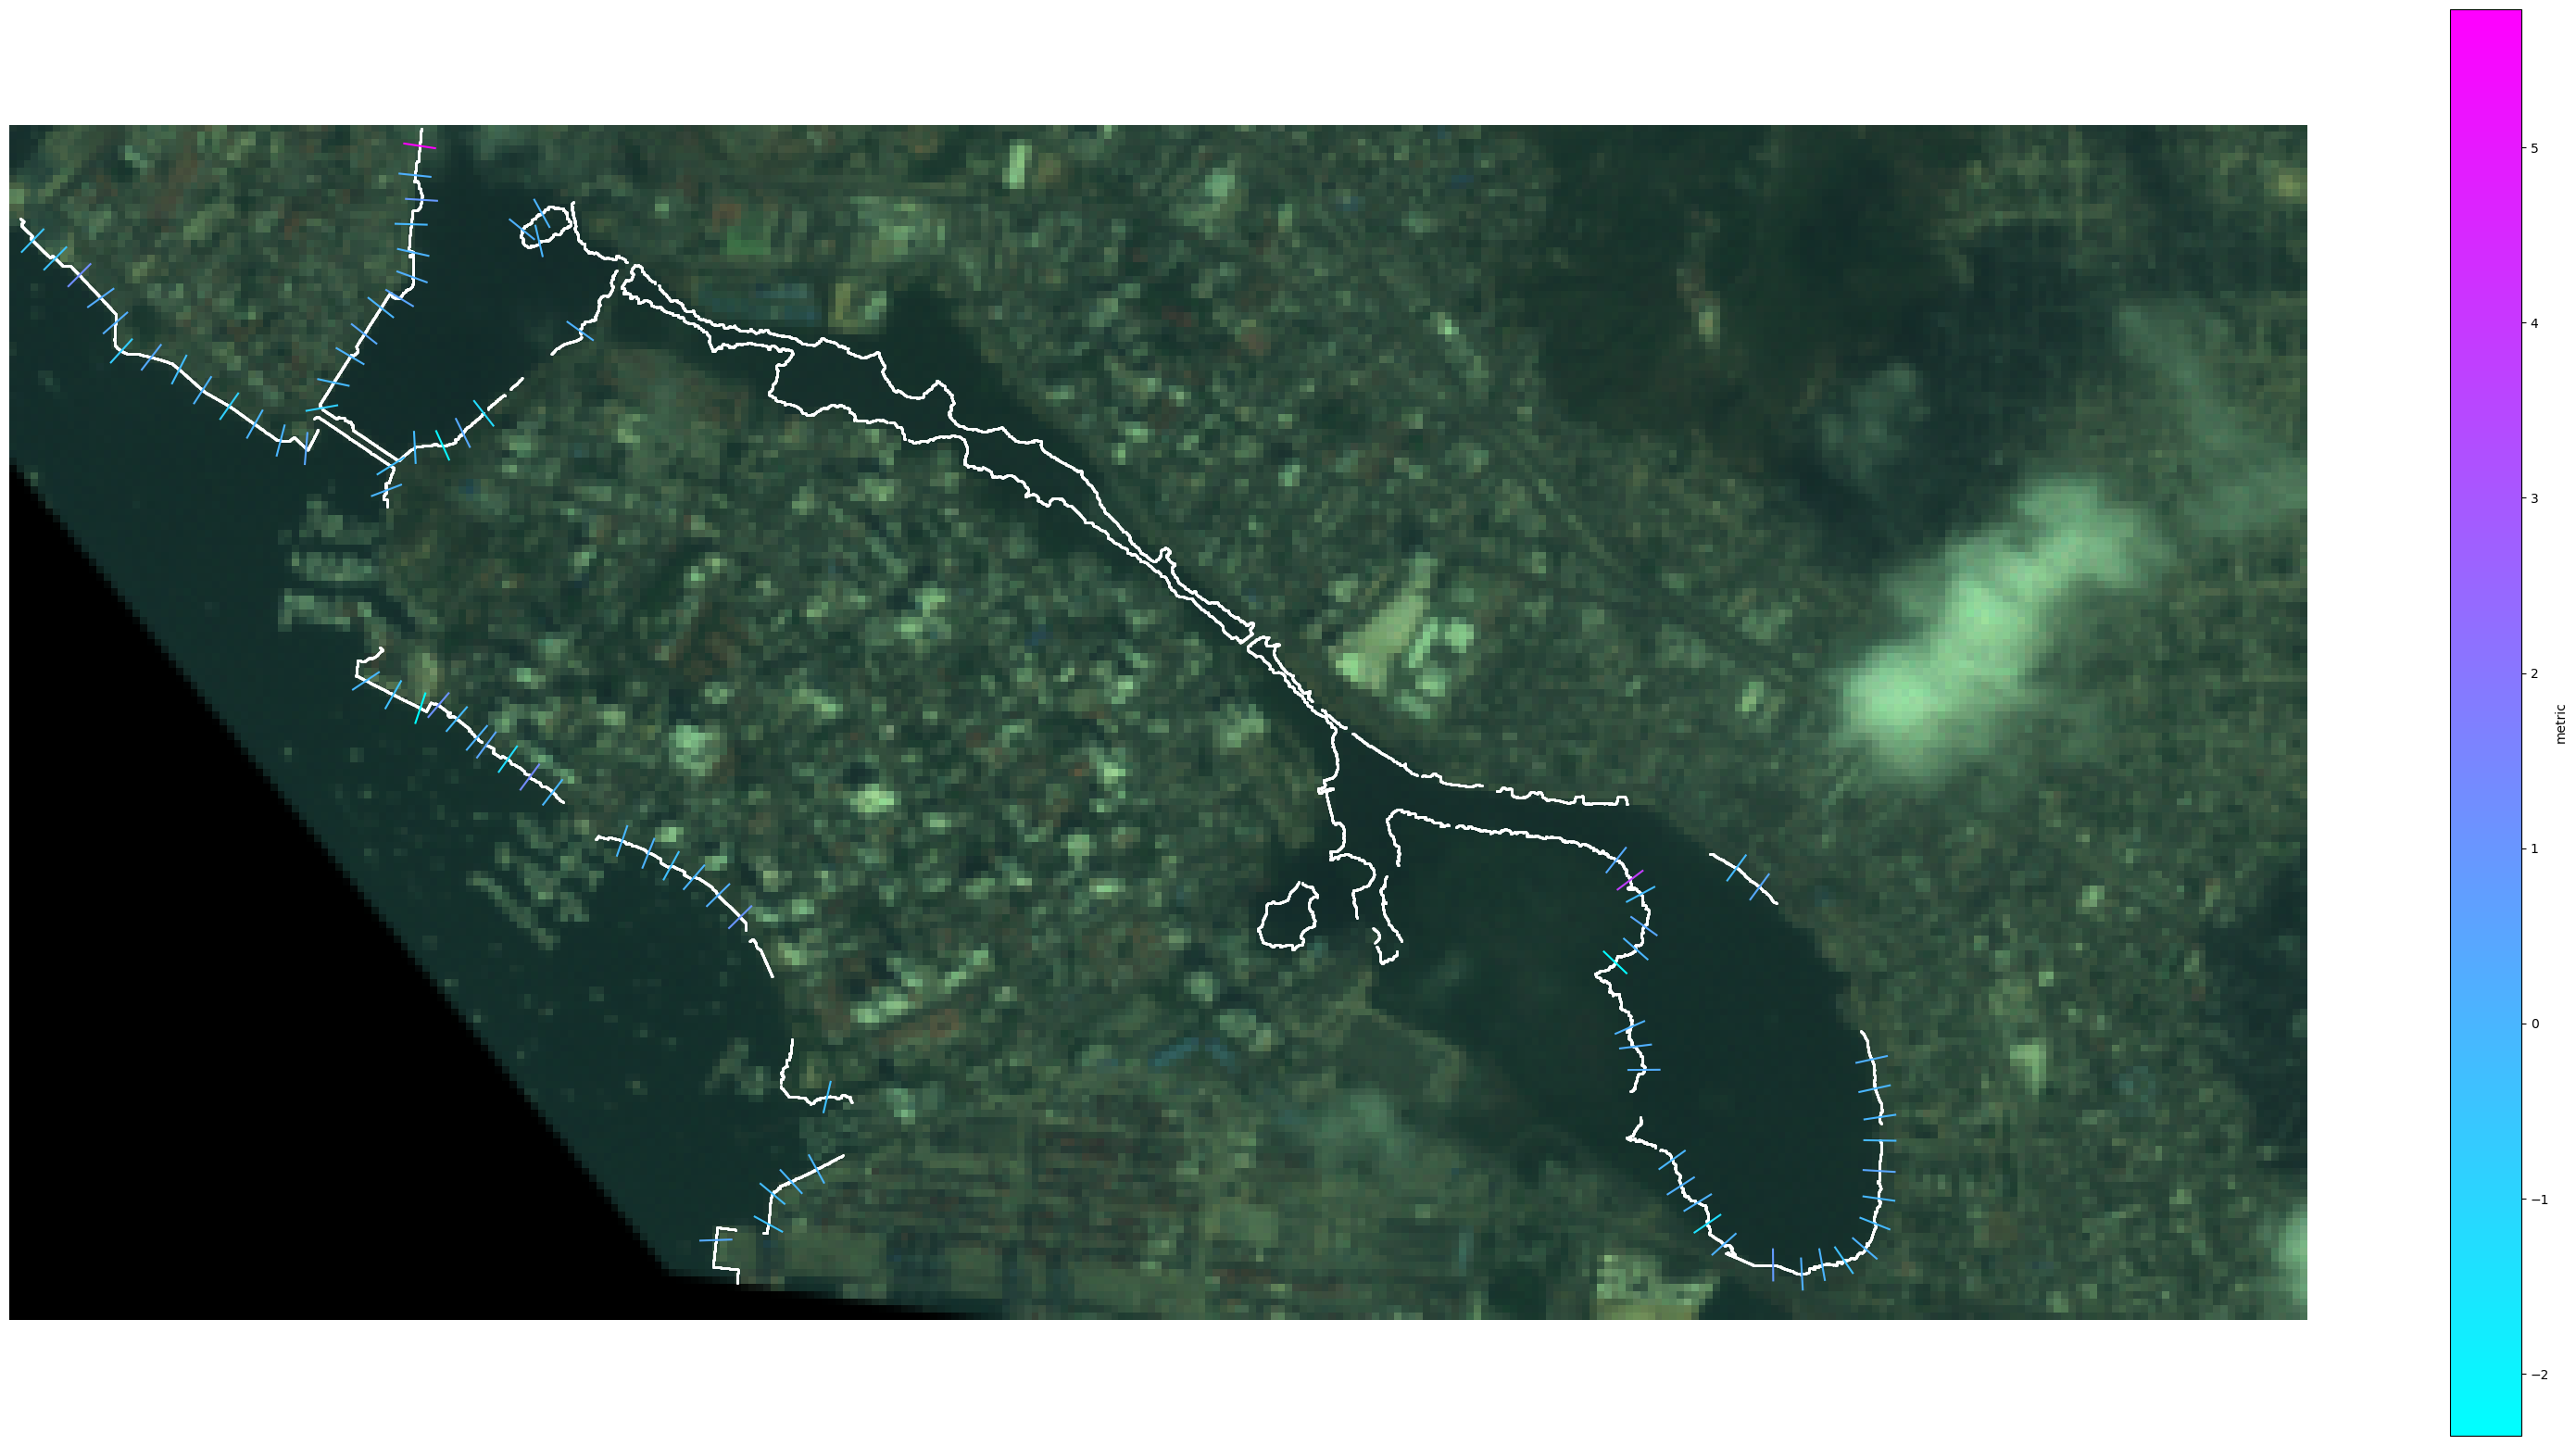

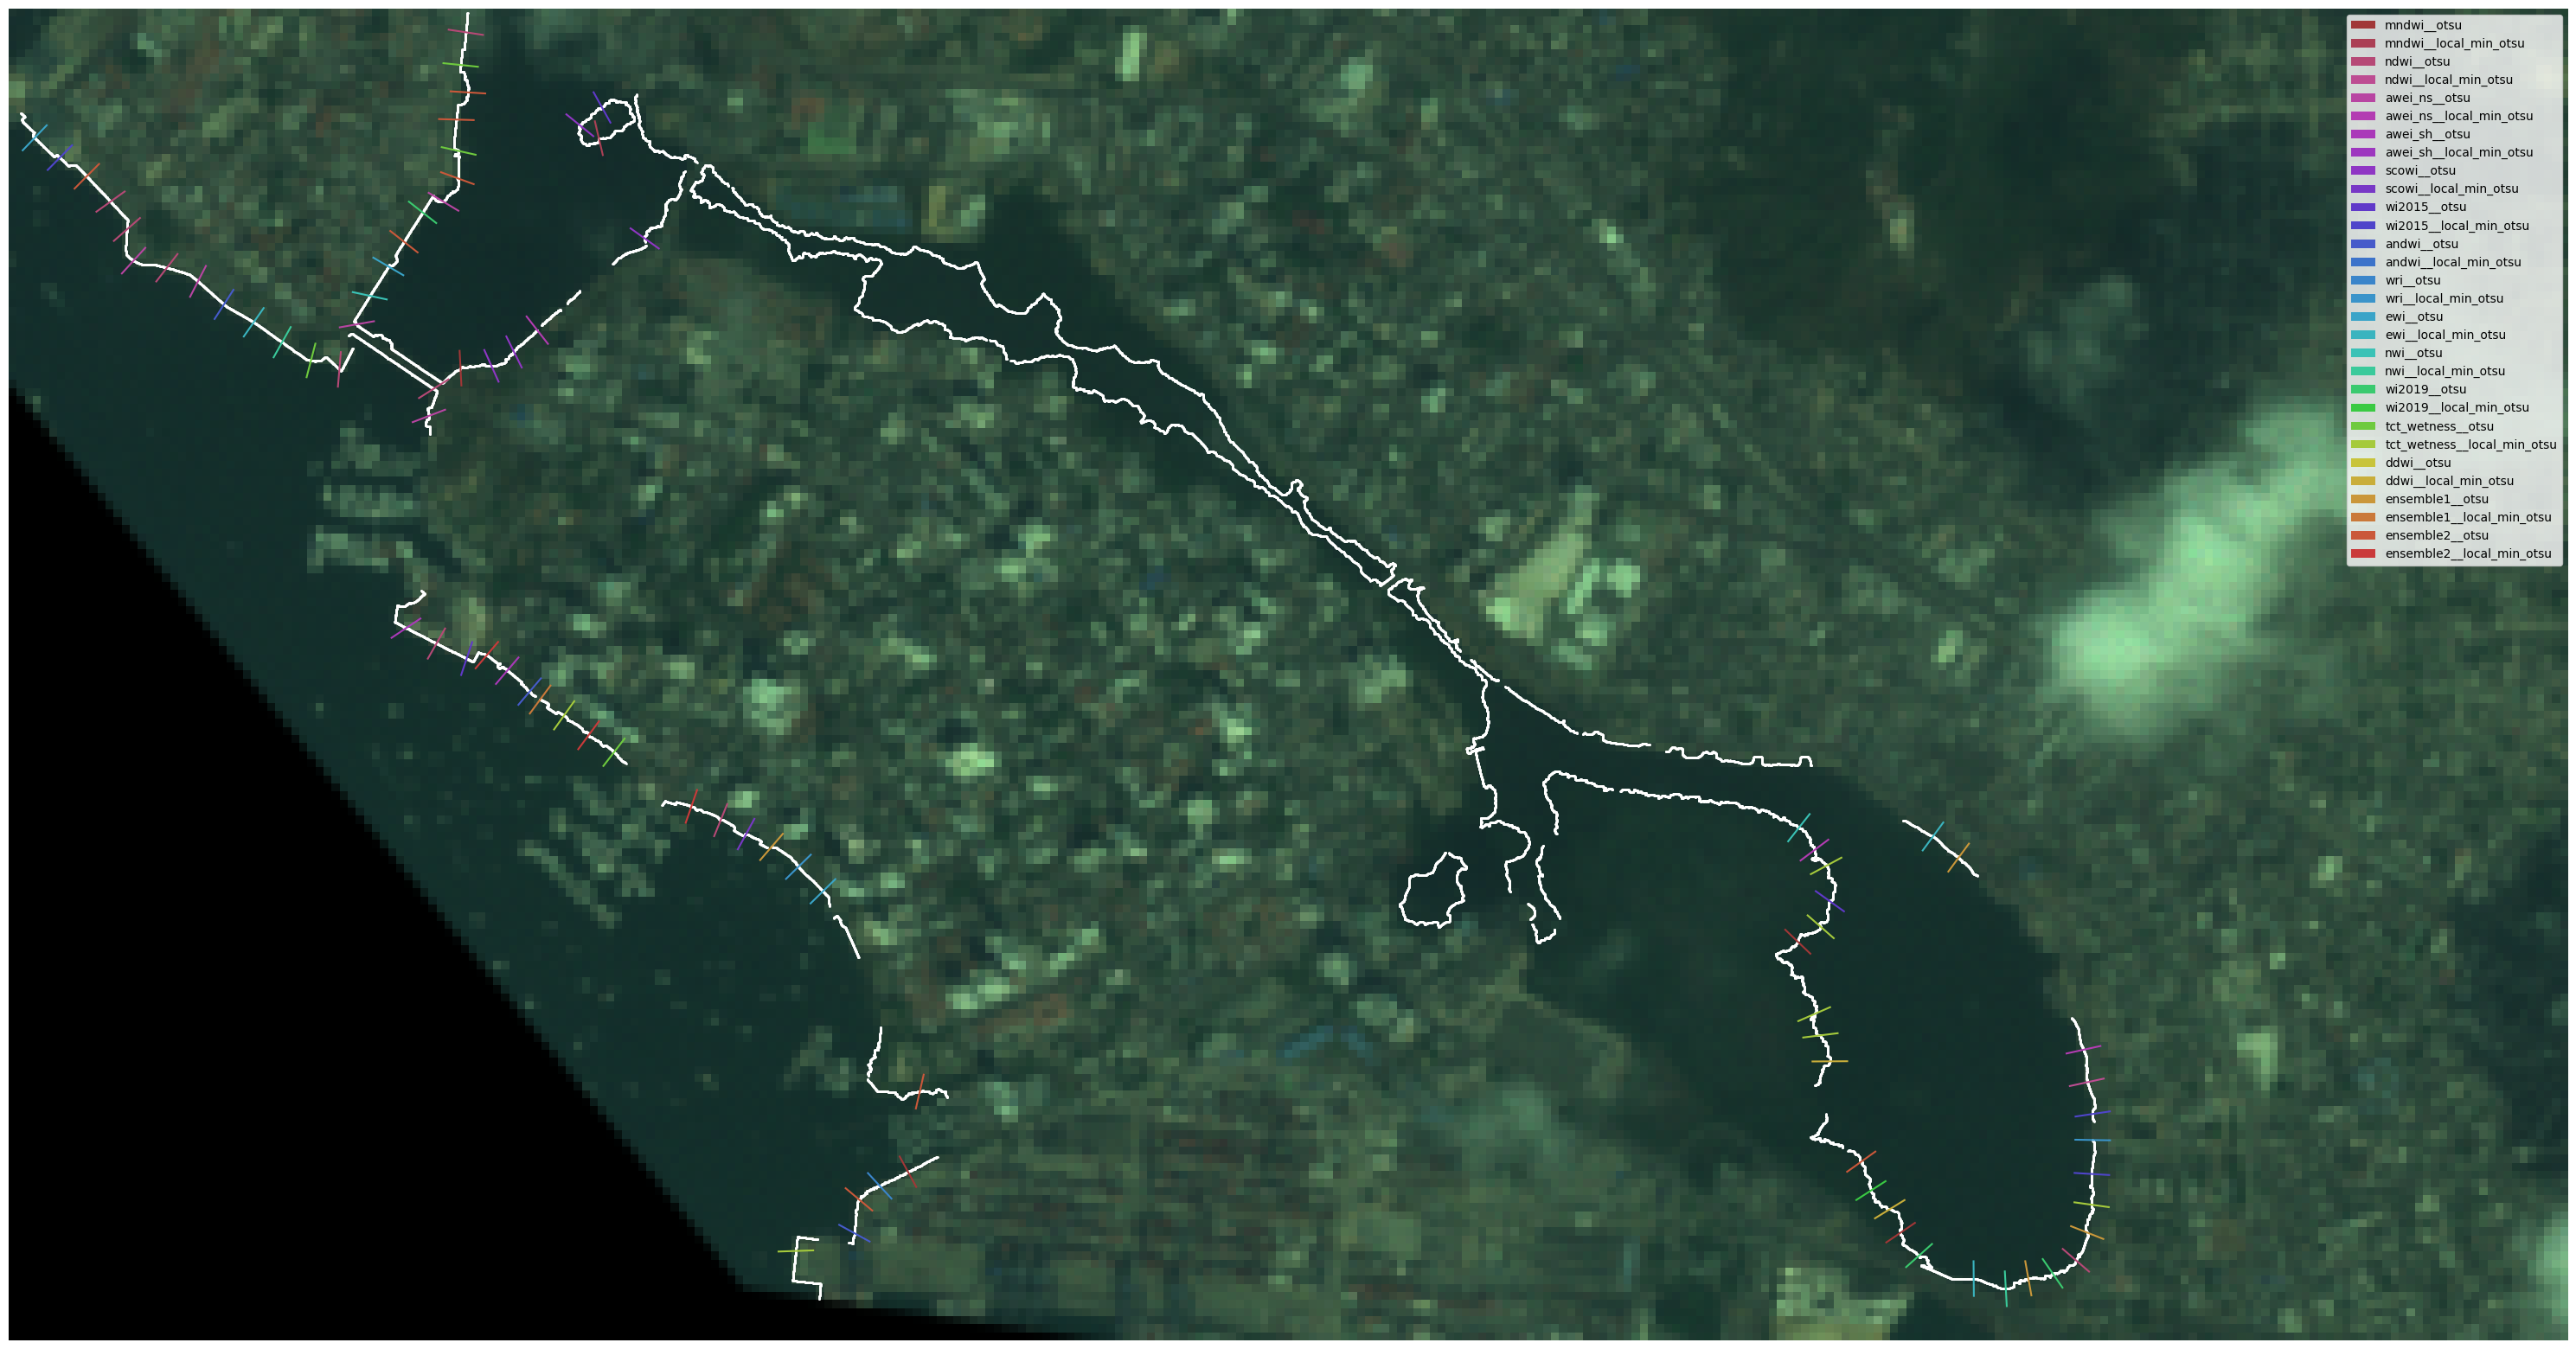

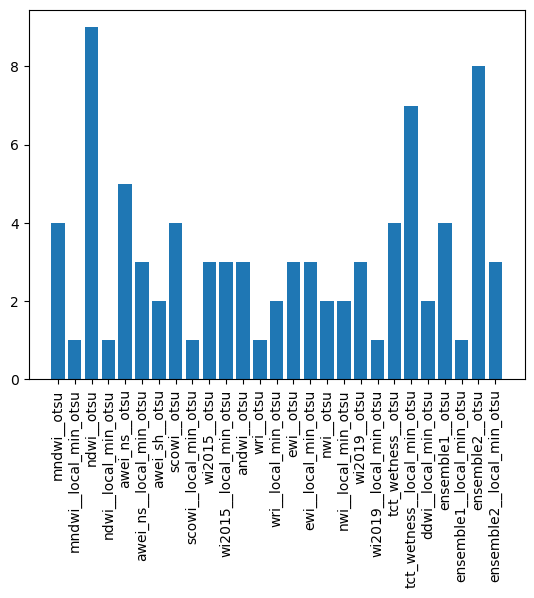

In [73]:
fig = wvep.plot_best_score_per_transect(t_values, transects_pix, ref_sl_points_pxl, im_rgb)
fig = wvep.plot_best_method_per_transect(best_per_transect_idx, methods, transects_pix, ref_sl_points_pxl, im_rgb)
fig = wvep.plot_best_method_counts(best_per_transect_idx, methods)

## Boxplots

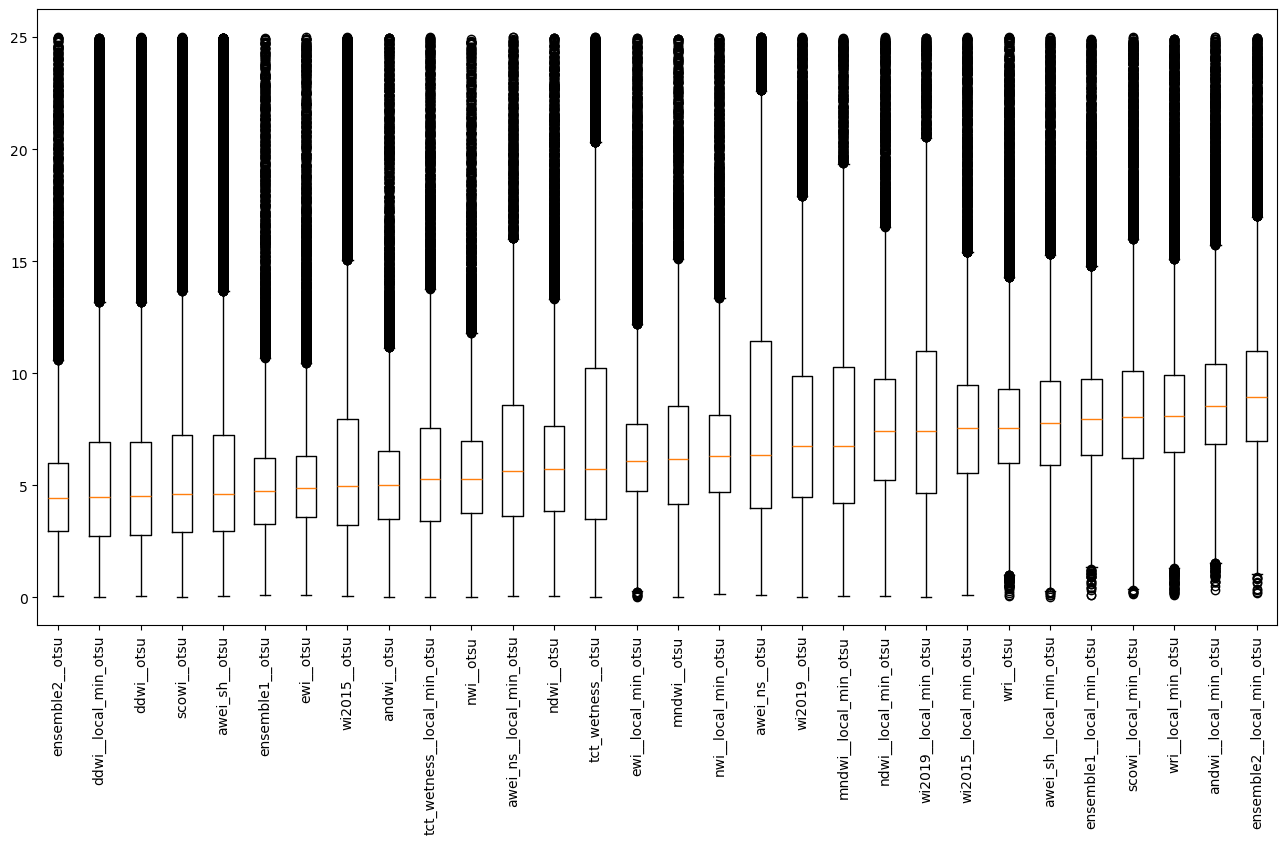

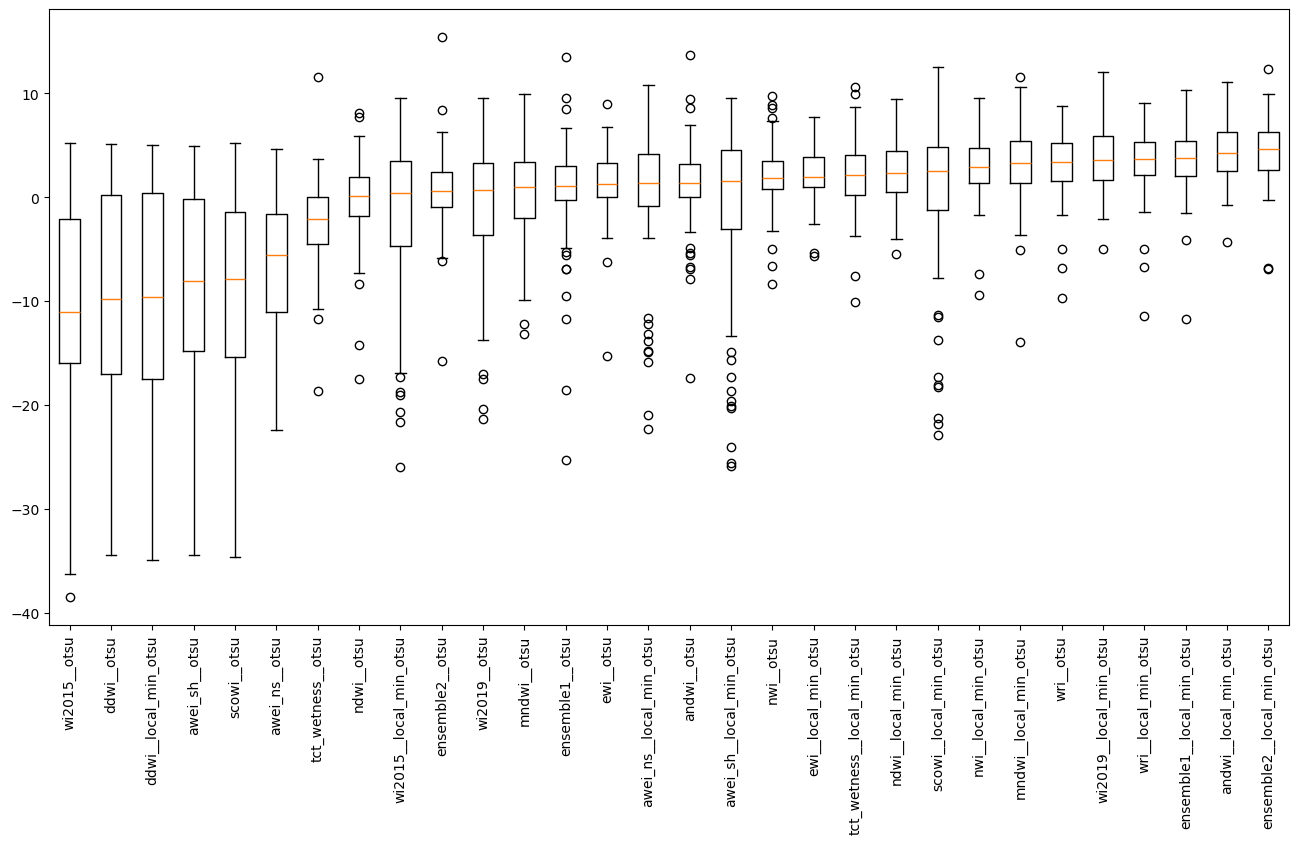

In [8]:
fig = wvep.violin_plots(shoreline_metric, methods, outlier_t=(0, 25), box_instead=True, sort_methods=True)
fig = wvep.violin_plots(transect_metric, methods, box_instead=True, sort_methods=True)

## Comparing Local Extraction Methods

Seems like basically noise, except for notable improvements on difficult areas (visible in improved sl_mean_all, sl_std, and n_outliers).

This is some more shaky evidence that WI are not proficient at representing sub-pixel water contents

WI2015 has some odd behaviour, maybe worth investigating, but for this location the index seems pretty garbage so why bother

Unclear if LSE1 or LSE2 is better

In [20]:
# define hand-partitioned zones
coords_pxl = ref_sl_points_pxl[::100]
zone_indicators = np.zeros((len(coords_pxl)), dtype=int)
zone_indicators[:80] = 0
zone_indicators[80:104] = 1
zone_indicators[104:119] = 2
zone_indicators[119:141] = 1
zone_indicators[141:146] = 2
zone_indicators[146:163] = 3
zone_indicators[163:189] = 4
zone_indicators[189:216] = 5
zone_indicators[216:221] = 2
zone_indicators[221:] = 6

shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)

lse1_shoreline_metric, lse1_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse1=True
)

lse2_shoreline_metric, lse2_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True
)

lse_sanity_shoreline_metric, lse_sanity_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True, zones=zone_indicators
)

entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)
lse1_entries, _ = wv_eval.organize_metrics(lse1_shoreline_metric, lse1_transect_metric, methods, outlier_idx)
lse2_entries, _ = wv_eval.organize_metrics(lse2_shoreline_metric, lse2_transect_metric, methods, outlier_idx)
lse_sanity_entries, _ = wv_eval.organize_metrics(lse_sanity_shoreline_metric, lse_sanity_transect_metric, methods, outlier_idx)

30it [00:11,  2.50it/s]
30it [00:38,  1.30s/it]
30it [00:14,  2.03it/s]
30it [00:13,  2.30it/s]


['sl_mean', 'sl_mean_all', 'sl_std', 'sl_n_outliers', 't_mean', 't_std', 't_mae']


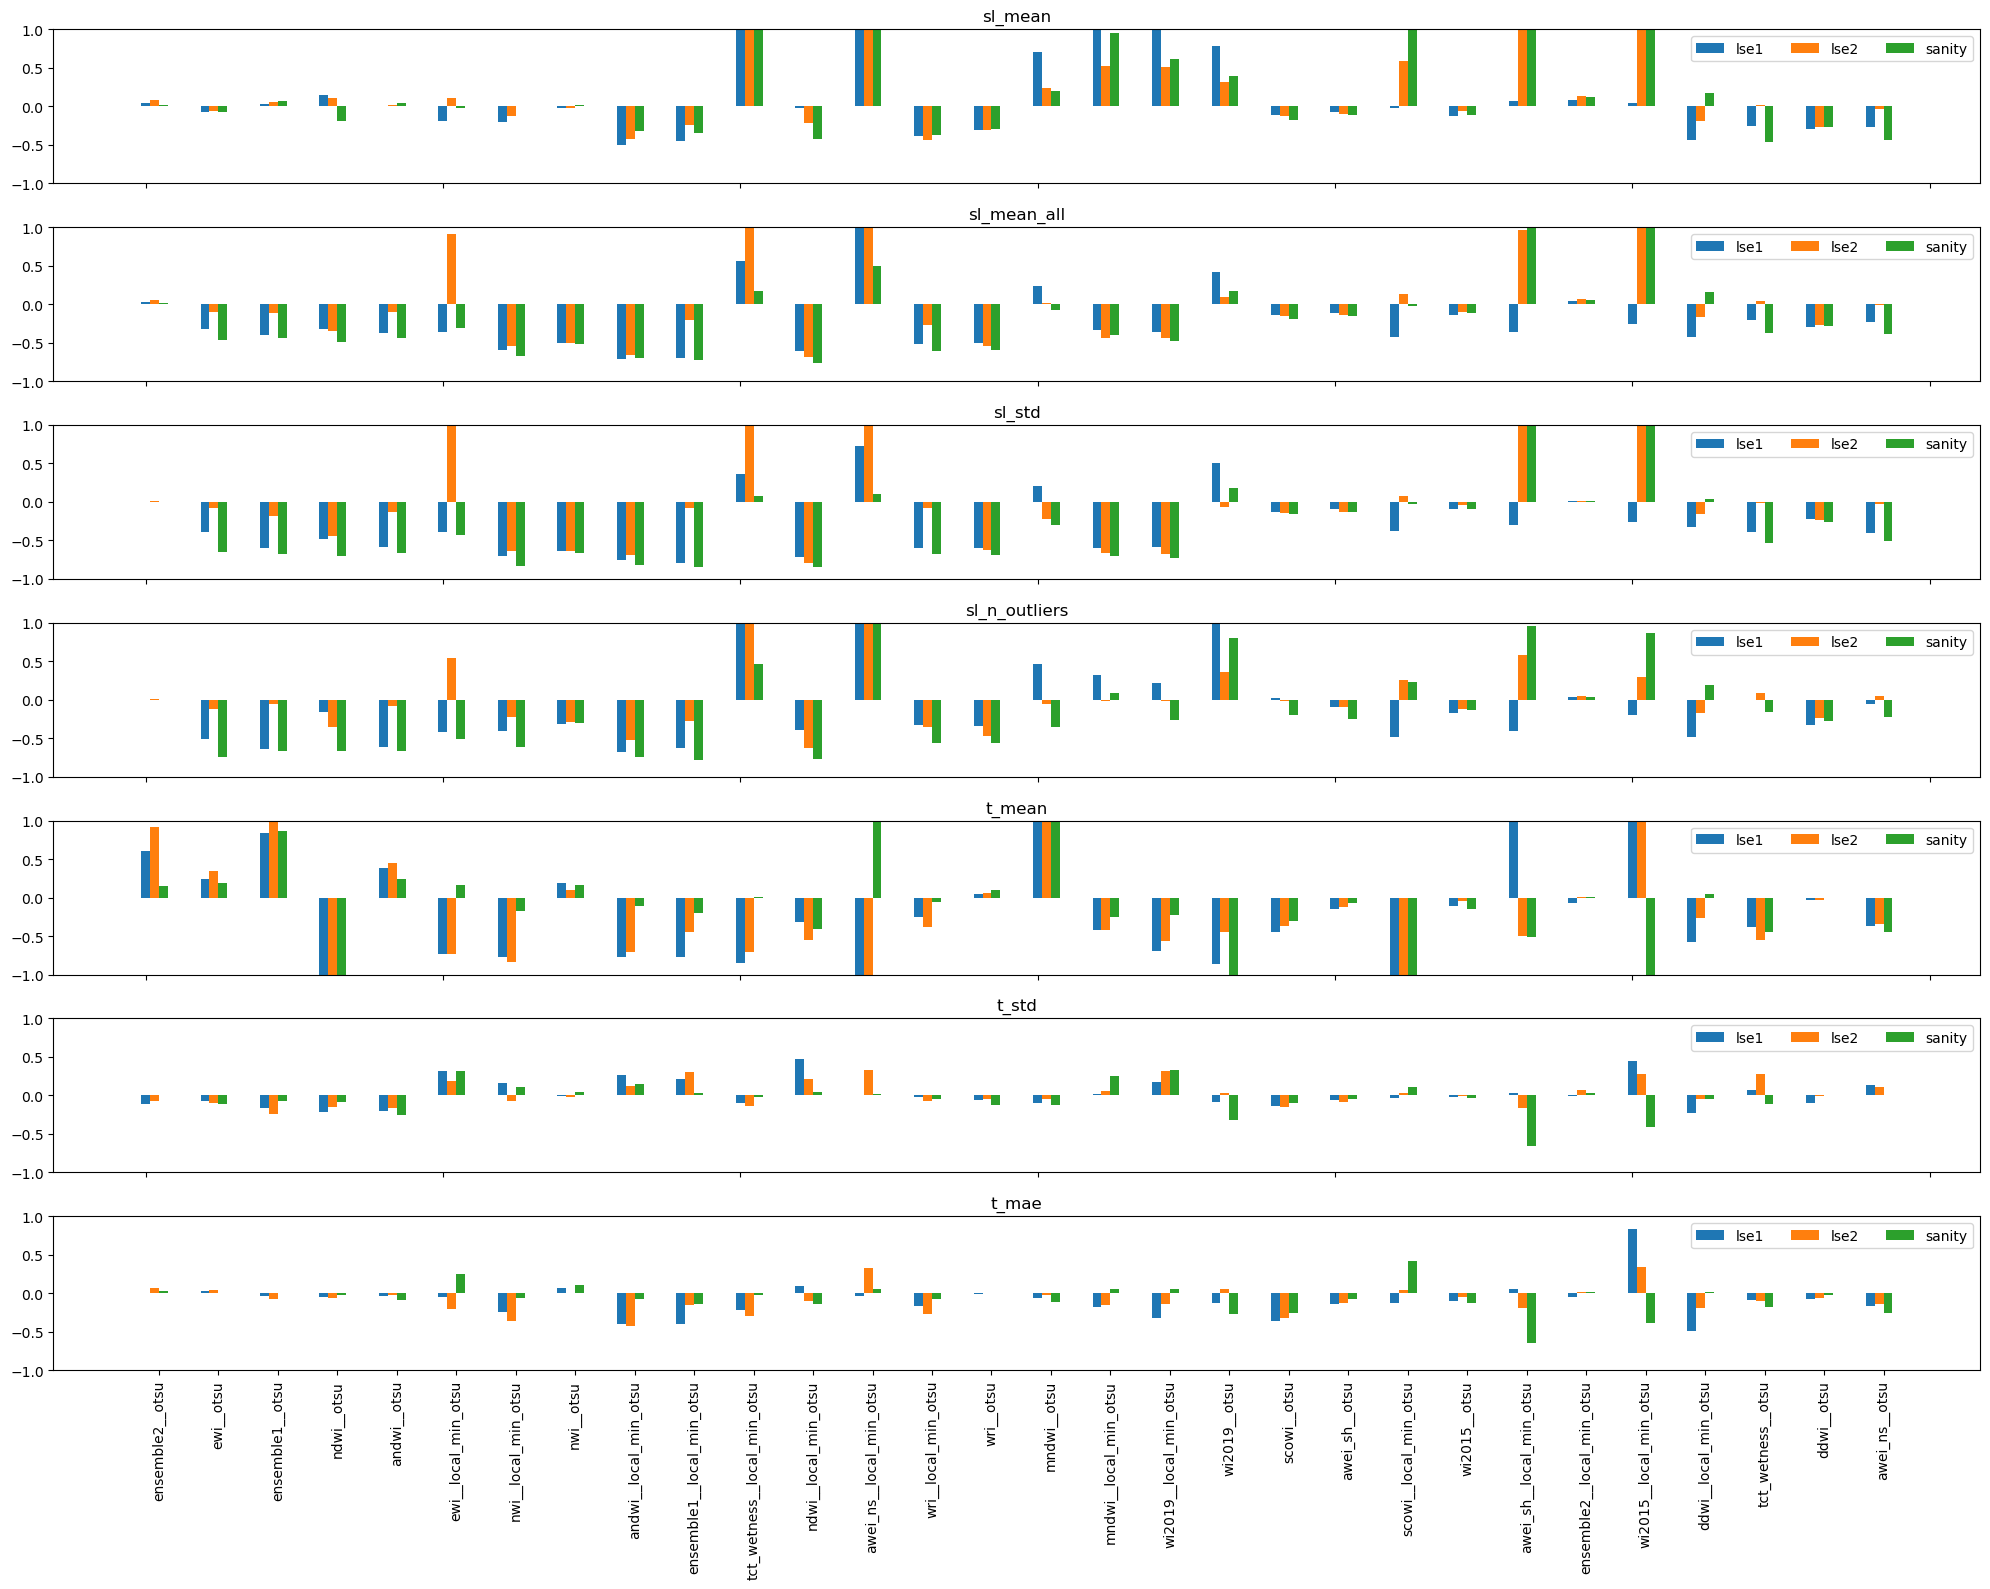

In [21]:
entries_arr = [entries, lse1_entries, lse2_entries, lse_sanity_entries]
titles = ["none", "lse1", "lse2", "sanity"]
fig = wvep.plot_comparison_barplot(entries_arr, titles)

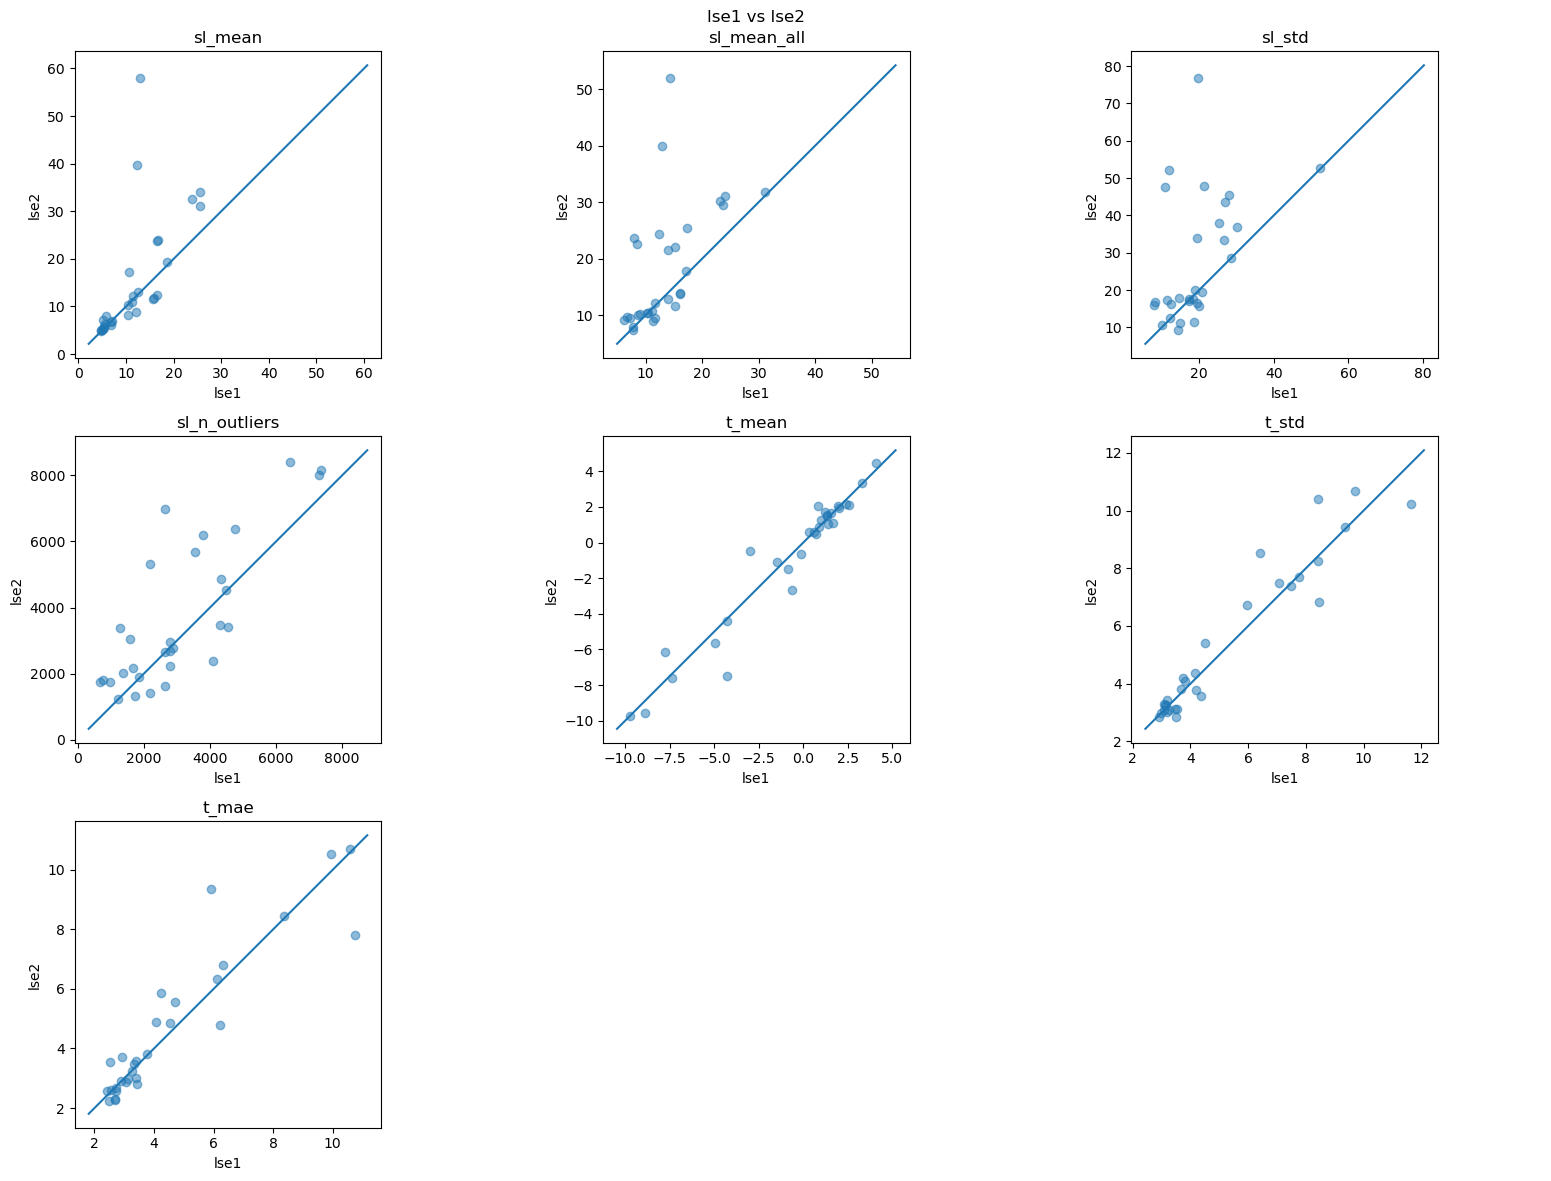

In [22]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(lse1_entries, lse2_entries, "lse1", "lse2", metrics, sl_lim=100)

## Optimal Thresholding

Gives small improvement, therefore thresholding methods seem pretty decent. Optimal threshold changes if ignoring/including outliers. This implies that the optimal threshold changes depending on the part of the image (support for a local thresholding methodology, at least for when there's difficult areas in a subsection of an image). Should refactor so isn't running every index twice (or just remove a thresholding method). Note that ensemble2 results differ as the threshold is applied to each index before binarizing and summing together

How much of improvement is overfitting to noise vs actually improving the index selection. I.e., is the improvement evidence of WI representing sub-pixel water contents (Note that if an optimal threshold was selected for every reference shoreline point, the extracted shoreline would match it perfectly)

In addition, noisier shorelines are inadvertently encouraged due to the flaw of the shoreline metric (t_mae gets worse)

(why are some sl_mean worse? is this a threshold resolution issue?)

In [36]:
# run with regular threshold_functions to get consistent outlier_idx
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

# run experiment
threshold_functions_temp = [otsu]
opt_shoreline_metric, opt_transect_metric, methods, opt_info = wv_eval.evaluate_methods(
    index_functions, threshold_functions_temp, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, optimal_thresholds=True
)
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions_temp, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)

# use outlier idx from run with all threshold functions for uniformity
entries, _ = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods, outlier_idx)
opt_entries, _ = wv_eval.organize_metrics(opt_shoreline_metric, opt_transect_metric, methods, outlier_idx)

30it [00:11,  2.55it/s]
15it [16:28, 65.87s/it]
15it [00:07,  1.95it/s]


In [37]:
wv_eval.print_metrics(opt_entries, "sl_mean")
print("\n")
wv_eval.print_metrics(entries, "sl_mean")

                                    sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
ensemble1__otsu:                    5.423        6.232        7.161        706            -2.809       6.700        4.866       
andwi__otsu:                        5.773        6.562        8.151        796            -2.945       6.634        4.860       
nwi__otsu:                          5.969        6.590        8.273        885            -2.773       5.844        4.612       
ensemble2__otsu:                    6.346        6.385        6.772        572            -3.212       6.047        4.758       
ewi__otsu:                          6.368        6.985        8.612        909            -3.622       5.362        4.802       
awei_ns__otsu:                      7.024        7.486        6.566        667            -2.038       6.685        5.238       
awei_sh__otsu:                      7.198        9.977        11.714       1884           -3.574 

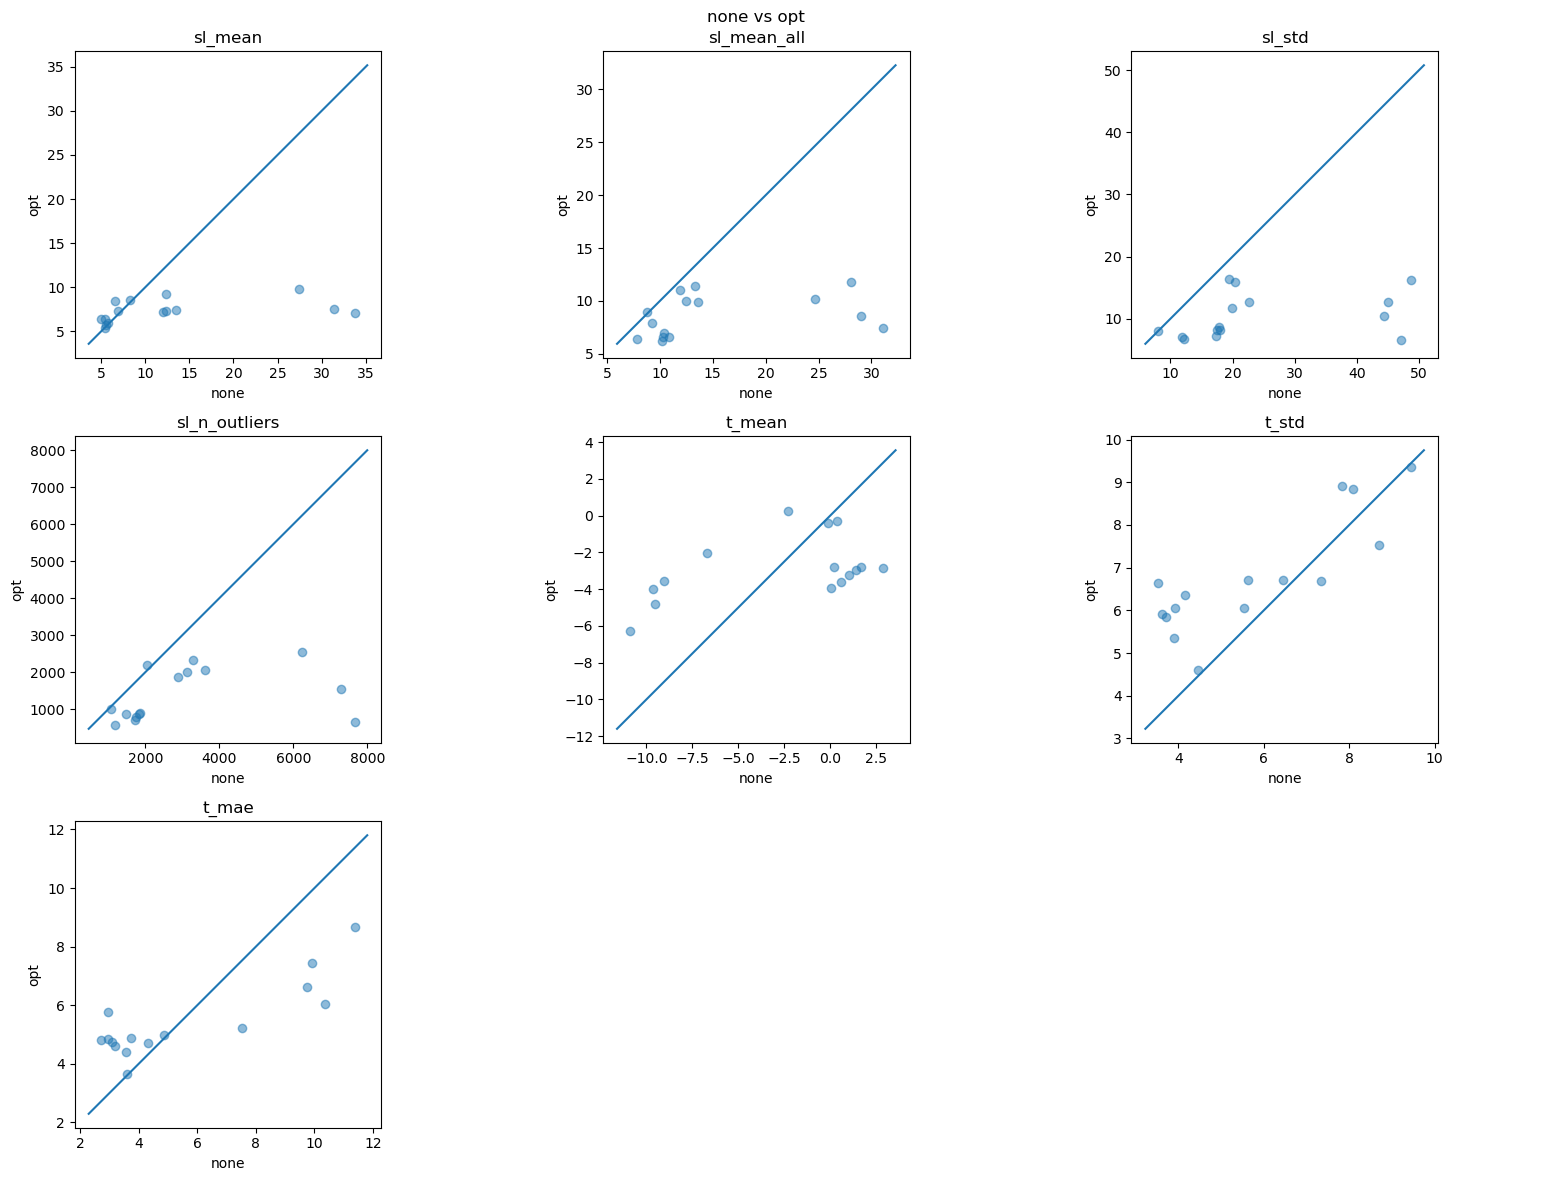

In [39]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(entries, opt_entries, "none", "opt", metrics, sl_lim=100)

### Optimizing entire shoreline, or omitting outlier

In [ ]:
im_ind = andwi(sim_bands.reshape(-1, sim_bands.shape[-1]))

In [ ]:
ignore_outliers_contours, ignore_outliers_threshold = wv_eval.get_optimal_threshold(im_ind.reshape(sim_bands.shape[:-1]), ref_sl_points, sds_data, outlier_idx=outlier_idx)
ignore_outliers_dists = m.get_nearest_distance(ref_sl_points, ignore_outliers_contours)
print(np.mean(ignore_outliers_dists))
print(np.mean(ignore_outliers_dists[~outlier_idx]))

9.688412532249526
5.045890616986989


In [35]:
inc_outliers_contours, inc_outliers_threshold = wv_eval.get_optimal_threshold(im_ind.reshape(sim_bands.shape[:-1]), ref_sl_points, sds_data)
inc_outliers_dists = m.get_nearest_distance(ref_sl_points, inc_outliers_contours)
print(np.mean(inc_outliers_dists))
print(np.mean(inc_outliers_dists[~outlier_idx]))

6.561689806491867
5.773254337348431


## Custom Spectral Unmixing

otsu_thresh = np.float32(0.30677205)
sl_mean: 4.8661352961105795, 7.616596654429929
t_mae: 2.1233014119634253


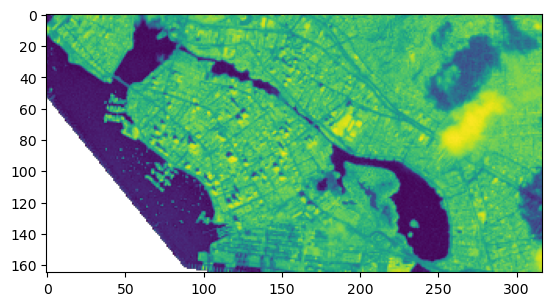

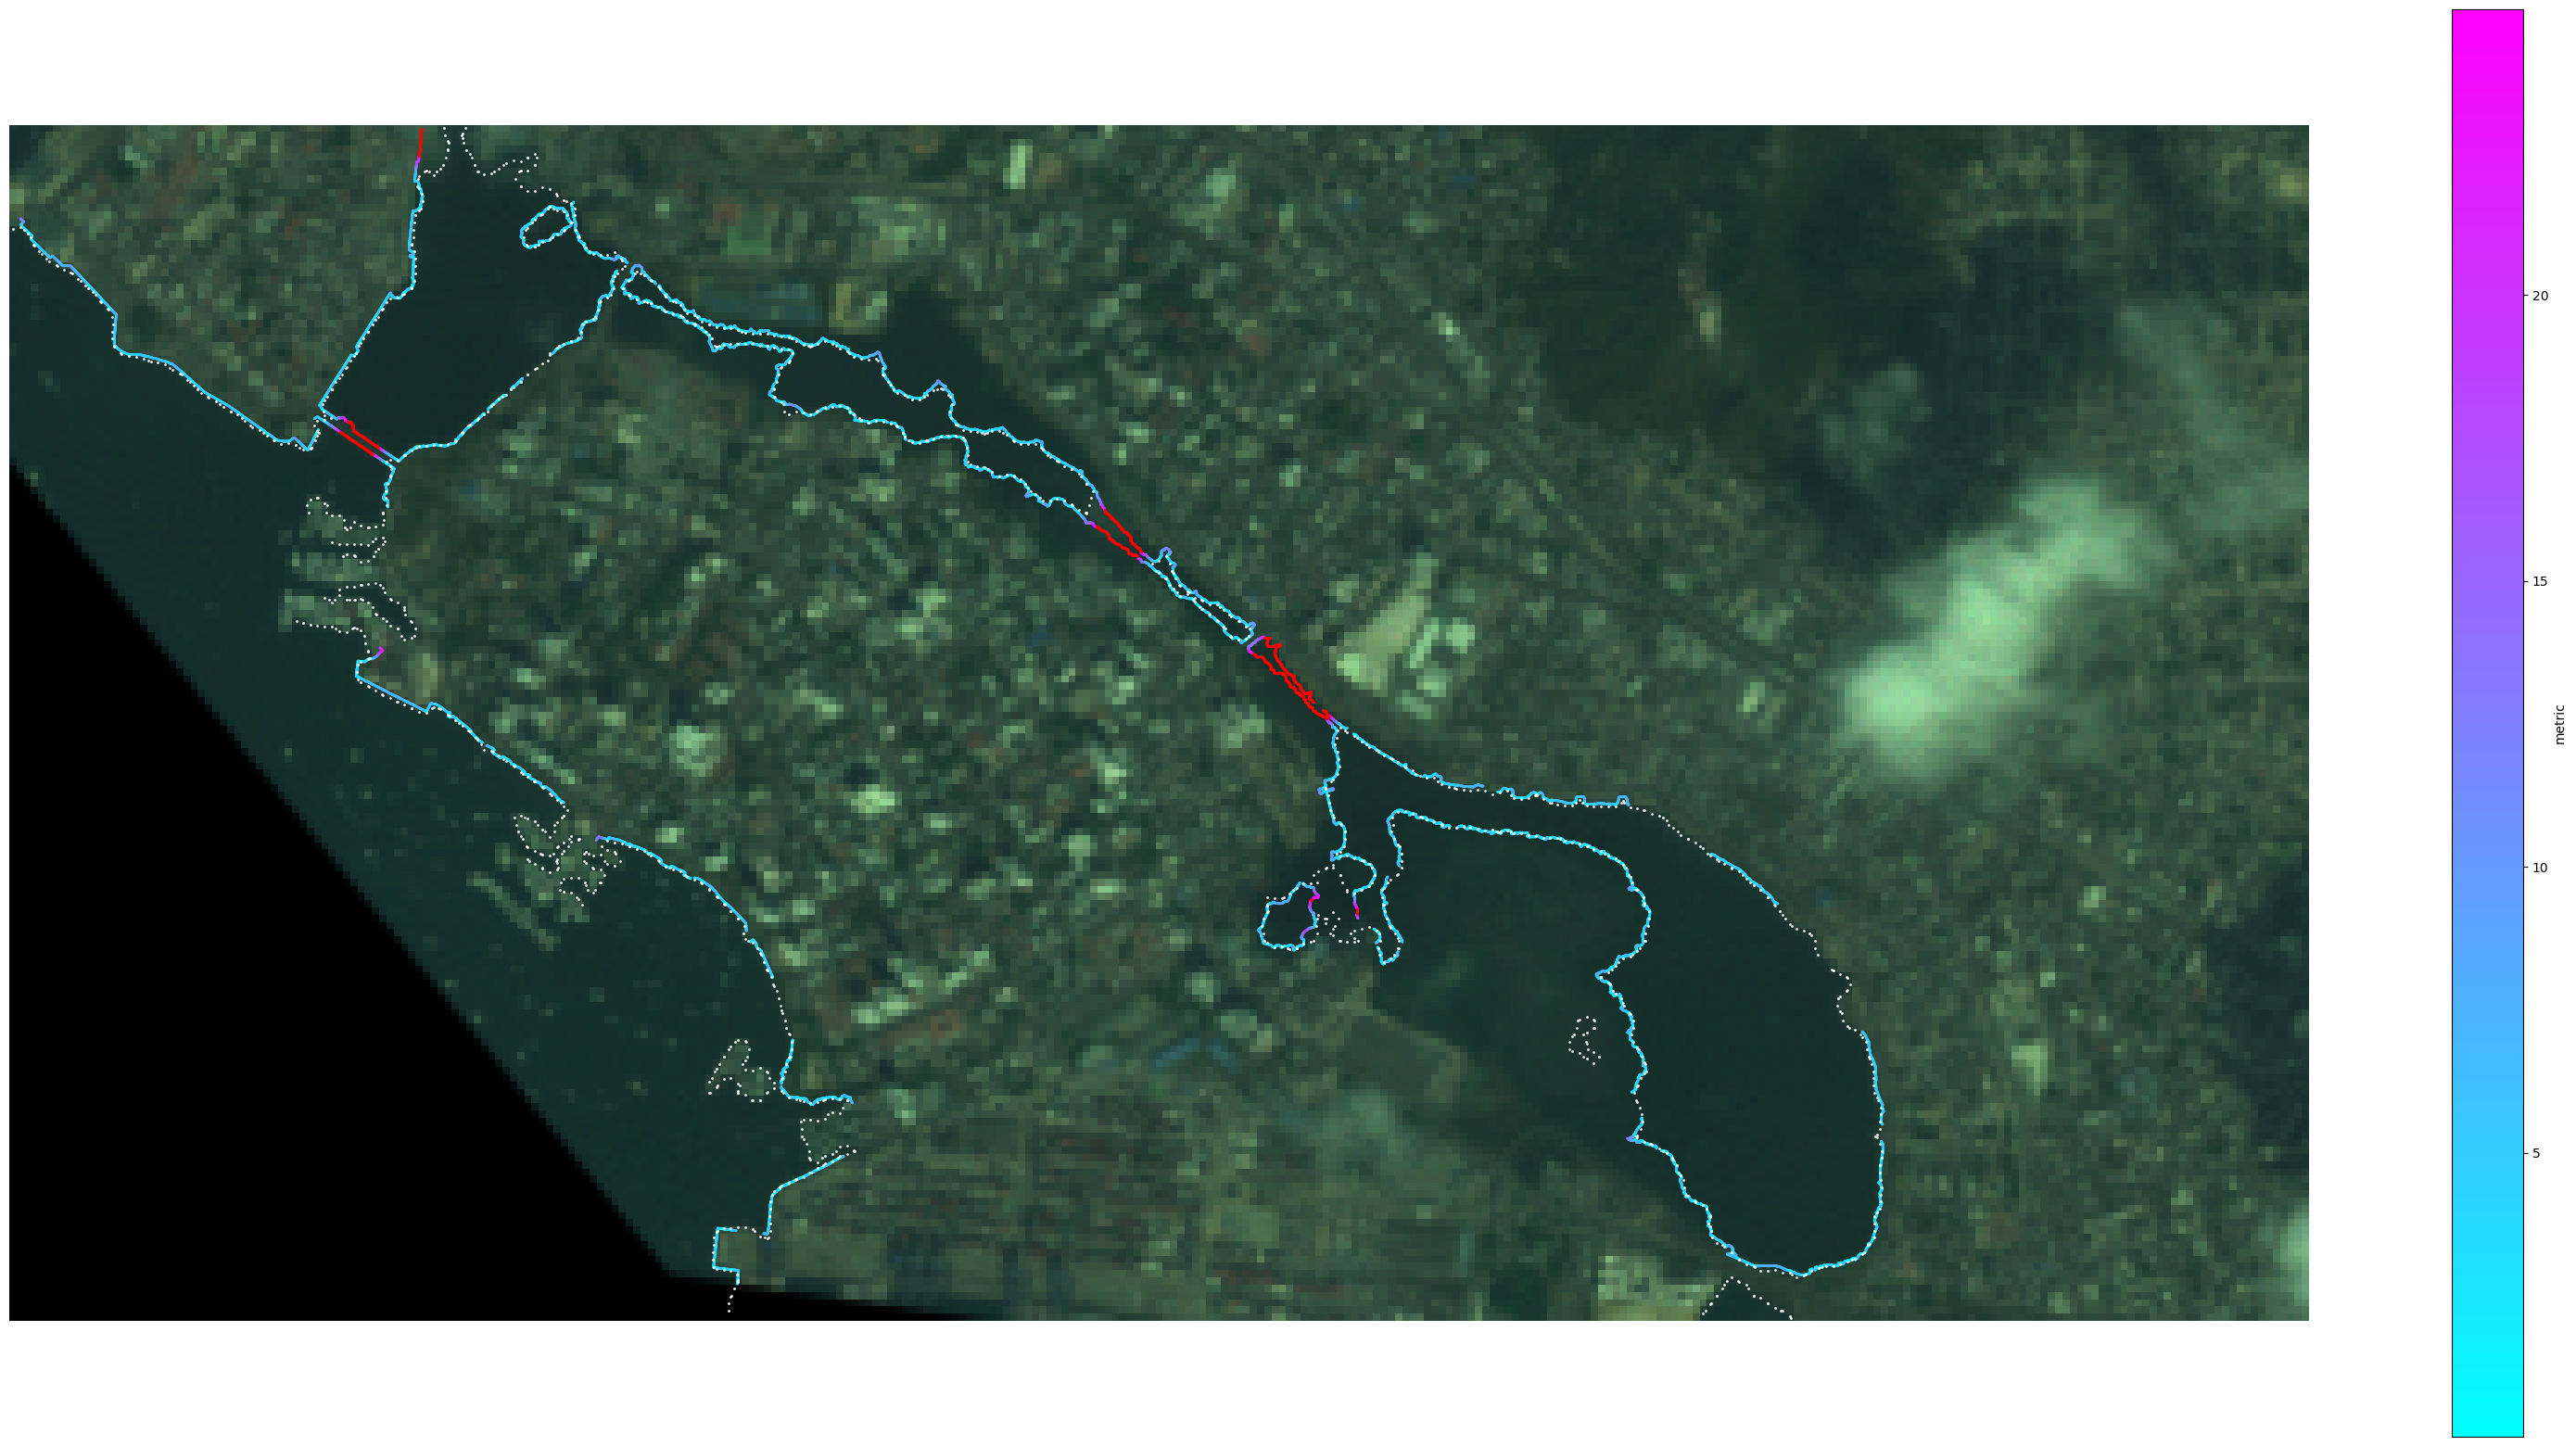

In [103]:
im_ind = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sl_buffer)
percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data)
plt.imshow(percentages.reshape(sim_bands.shape[:-1]))

otsu_thresh = otsu(percentages, cloud_mask, sl_buffer)
contours = wv_eval.get_contours(percentages.reshape(sim_bands.shape[:-1]), otsu_thresh, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

print(f"{otsu_thresh = }")
print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
contour_pxl = SDS_tools.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, im_rgb, contours_pxl=contour_pxl)

### Hand Partitioned LSE

bool bool bool
thresholds = [np.float32(0.30623242), np.float32(0.33141387), np.float32(0.37367323), np.float32(0.33253878), np.float32(0.27336365), np.float32(0.29107642), np.float32(0.36523724)]
sl_mean: 4.899789256557272, 5.529445094884048
t_mean: 2.2183860040365713


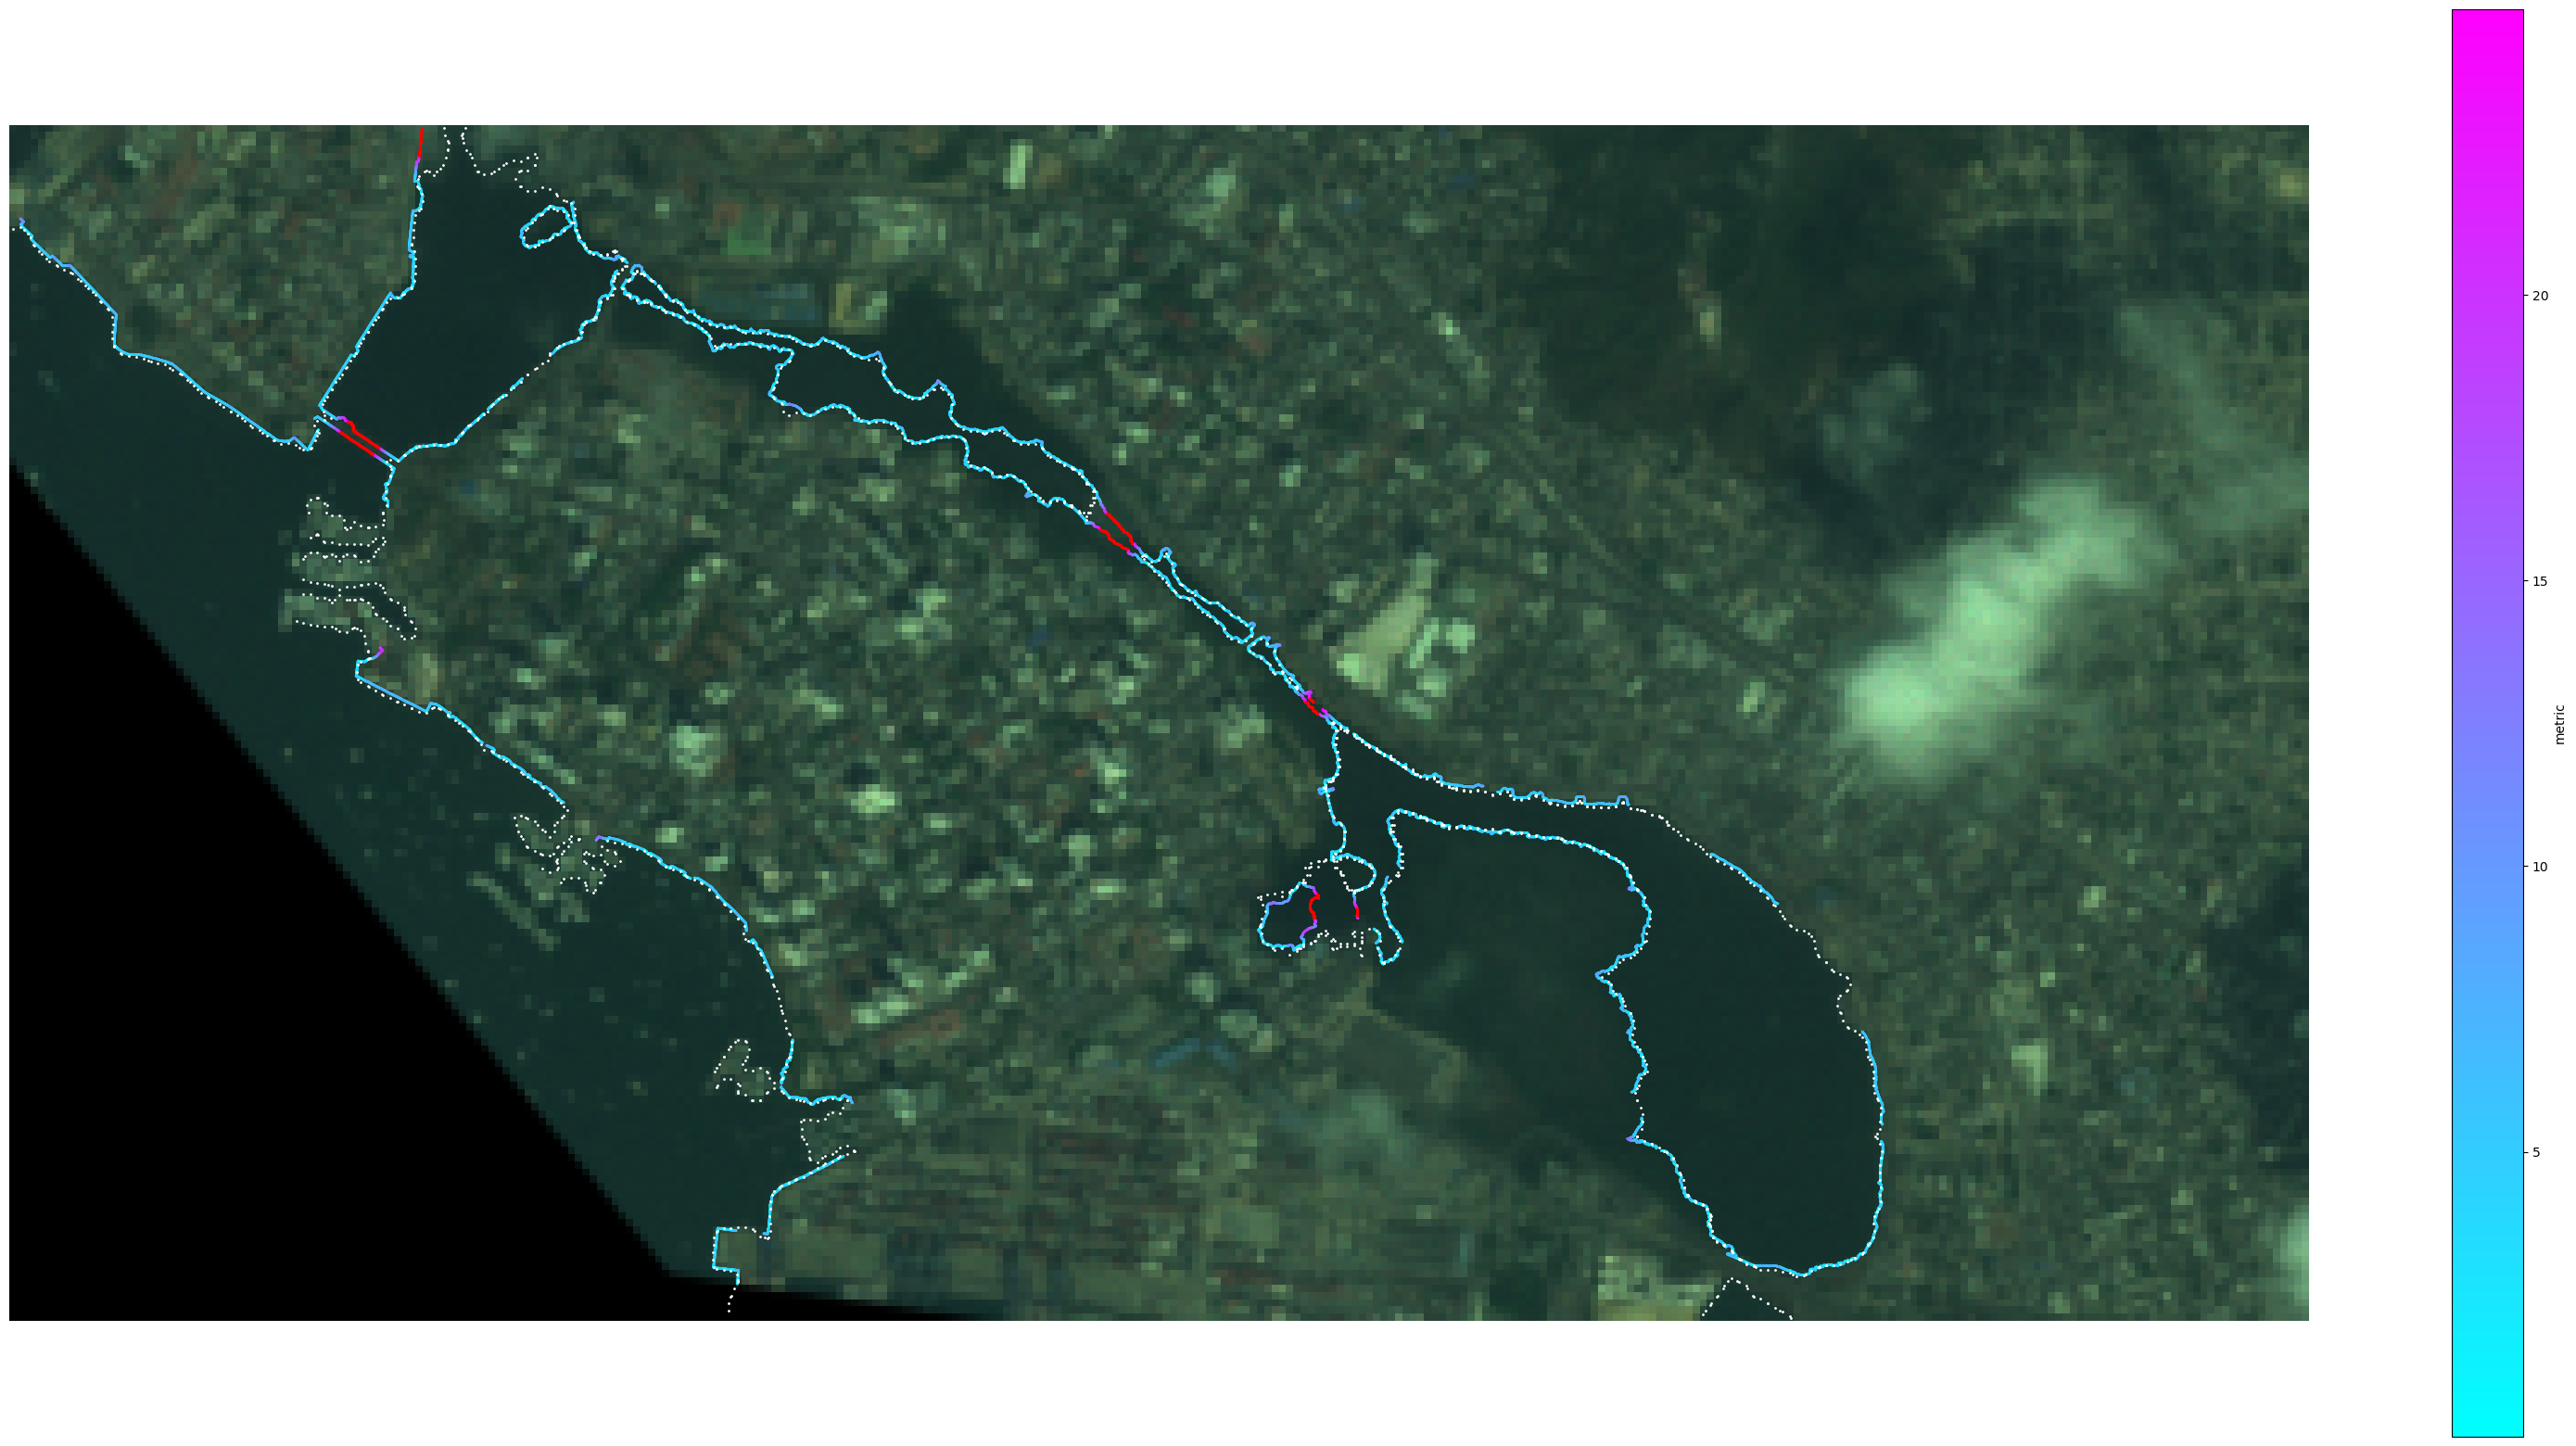

In [39]:
sanity_masks = lse.get_masks_from_zone_indicators(zone_indicators, coords_pxl, sim_bands.shape[:-1])
im_ind = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sl_buffer)
percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data).reshape(sim_bands.shape[:-1])

# contours, thresholds = lse.local_sl_extraction_su(sim_bands, sanity_masks, otsu, sds_data, im_ind=im_ind) # update candidate signature every buffer (and vary threshold)
contours, thresholds = lse.local_sl_extraction_su(sim_bands, sanity_masks, otsu, sds_data, percentages=percentages) # have one candidate signature for all buffers (only vary threshold)

sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)
contour_pxl = SDS_tools.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, im_rgb, contours_pxl=contour_pxl)

print(f"{thresholds = }")
print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mean: {np.nanmean(np.abs(t_dists))}")

## Combinations of Note

sl_mean: 4.641239714597806, 7.550702459713852
t_mae: 2.4148515125405052


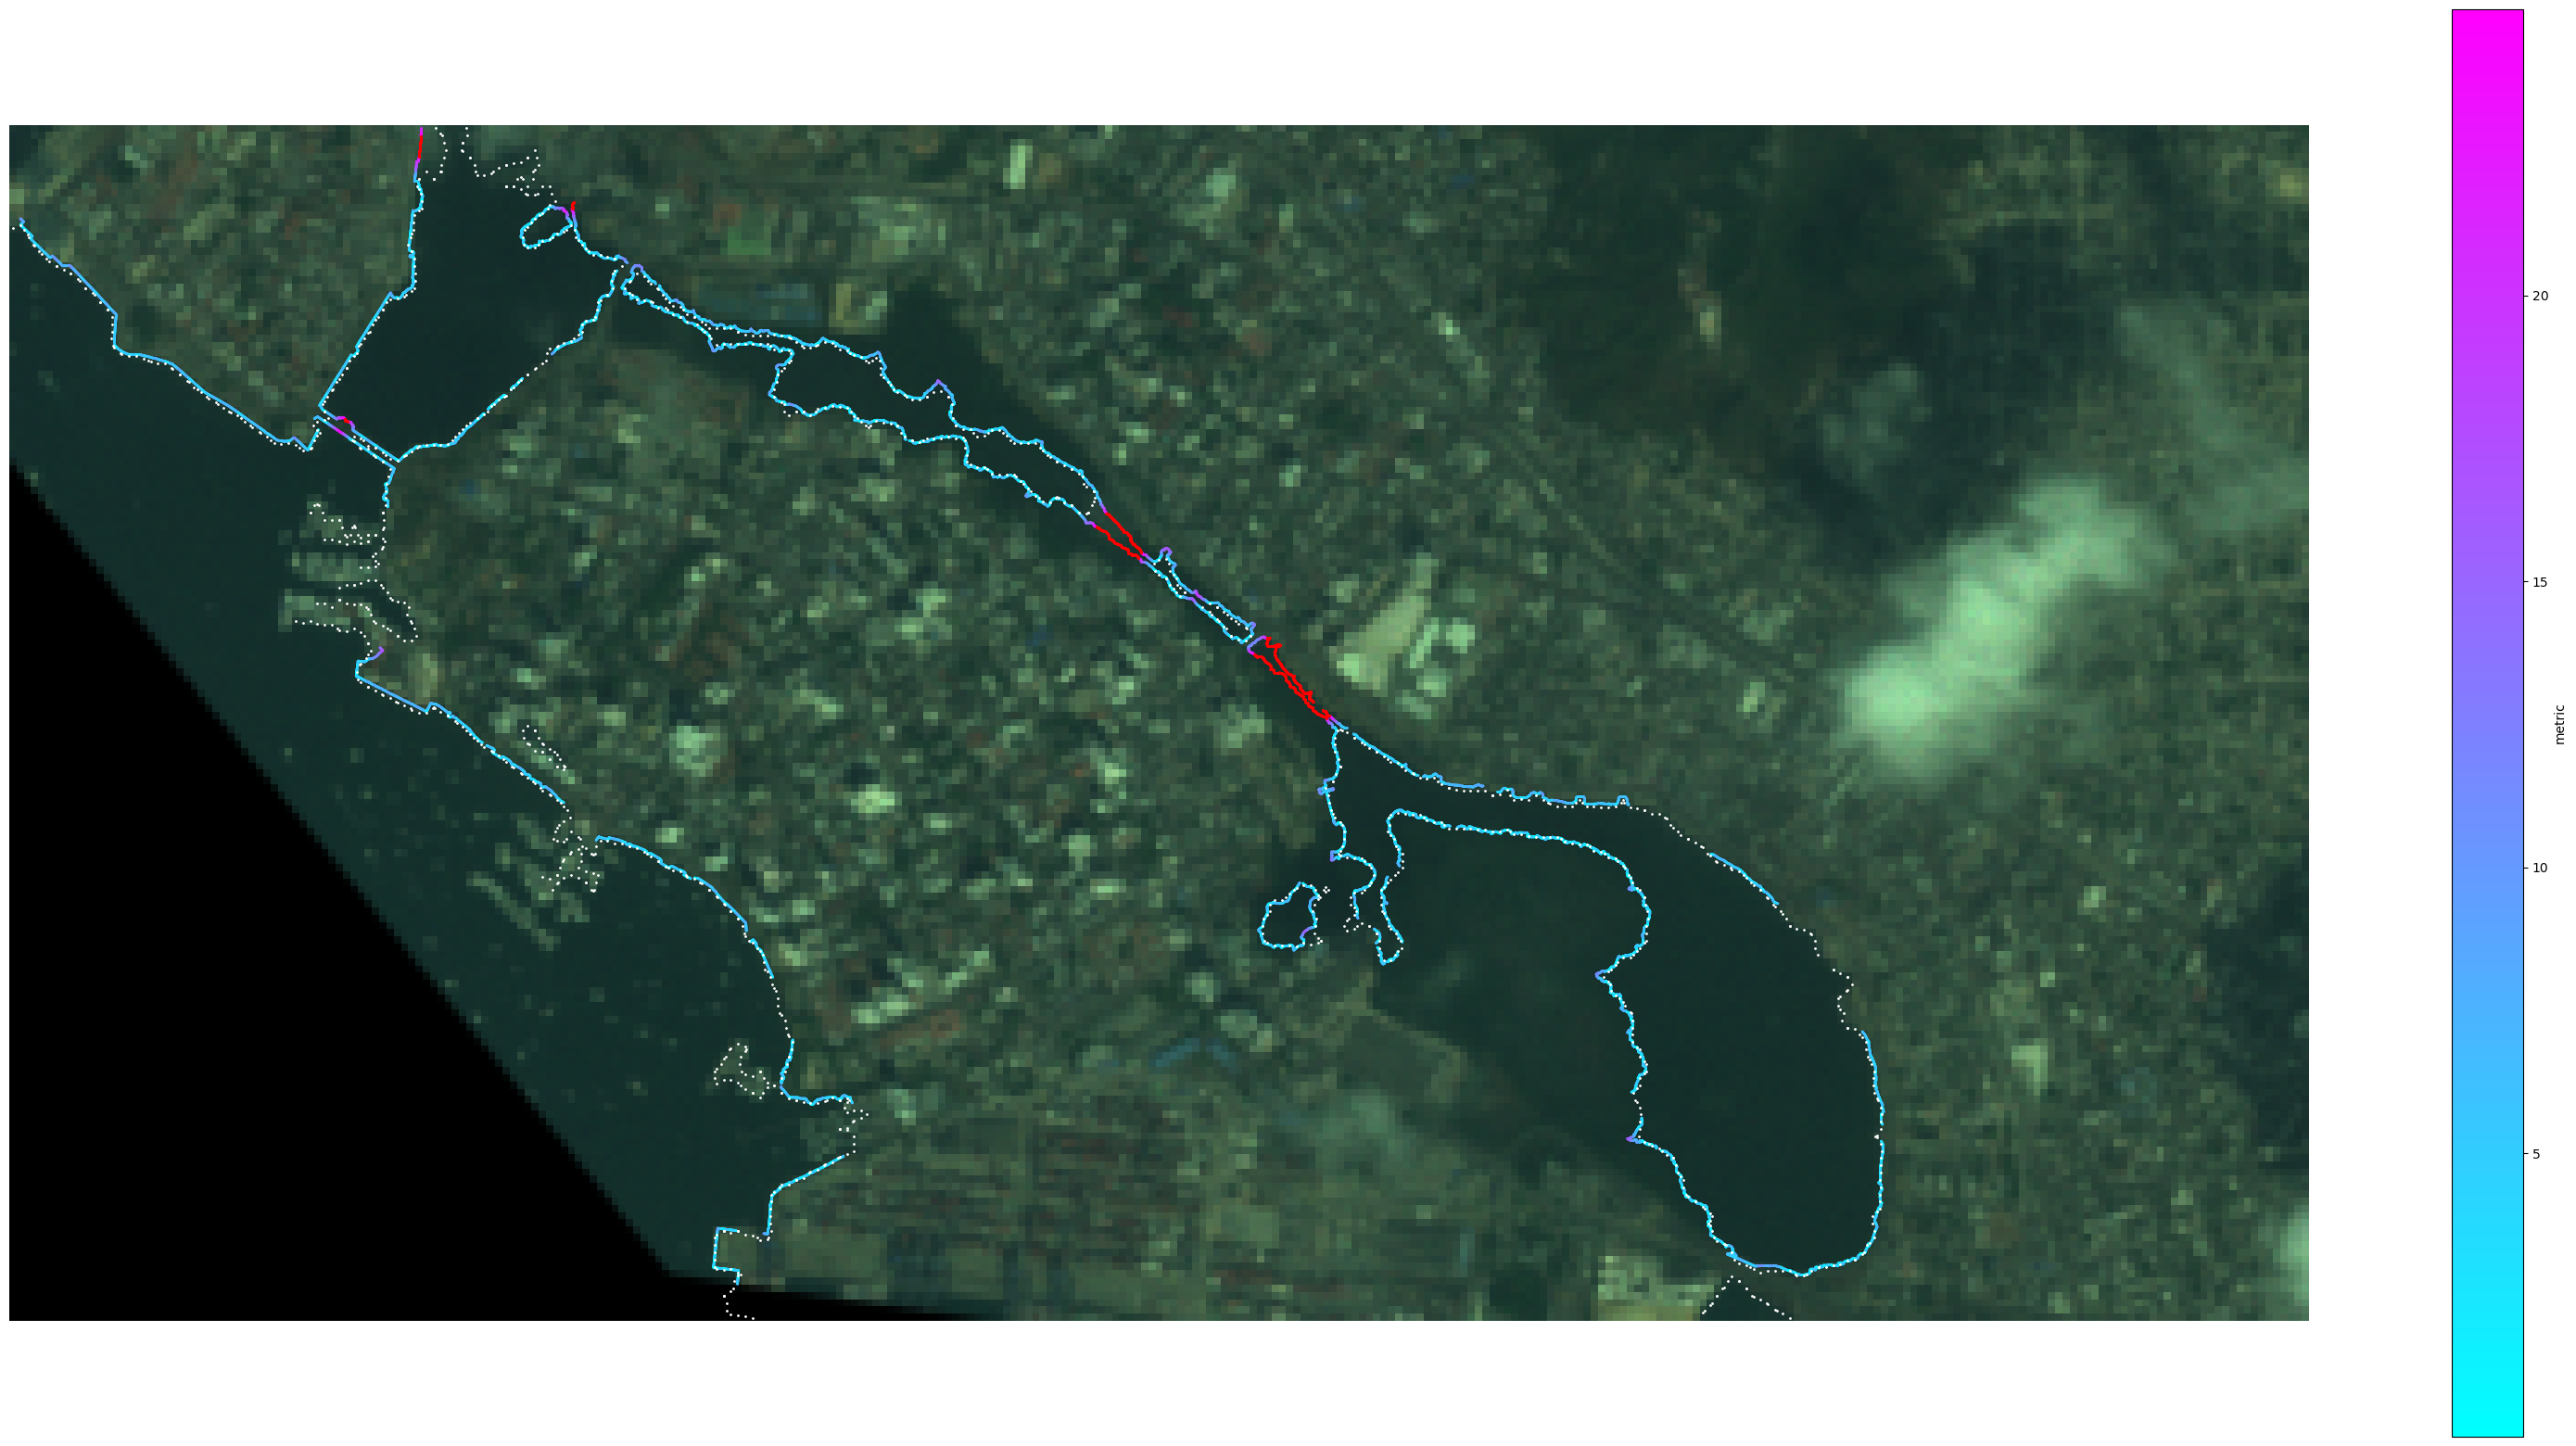

In [6]:
# Ensemble2 + Otsu
index = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sl_buffer)
threshold = otsu(index, cloud_mask, sl_buffer)

contours = wv_eval.get_contours(index.reshape(sim_bands.shape[:-1]), threshold, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

contour_pxl = SDS_tools.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, im_rgb, contours_pxl=contour_pxl)

print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")

sl_mean: 5.836685615124253, 11.08139486597895
t_mae: 3.185377235946632


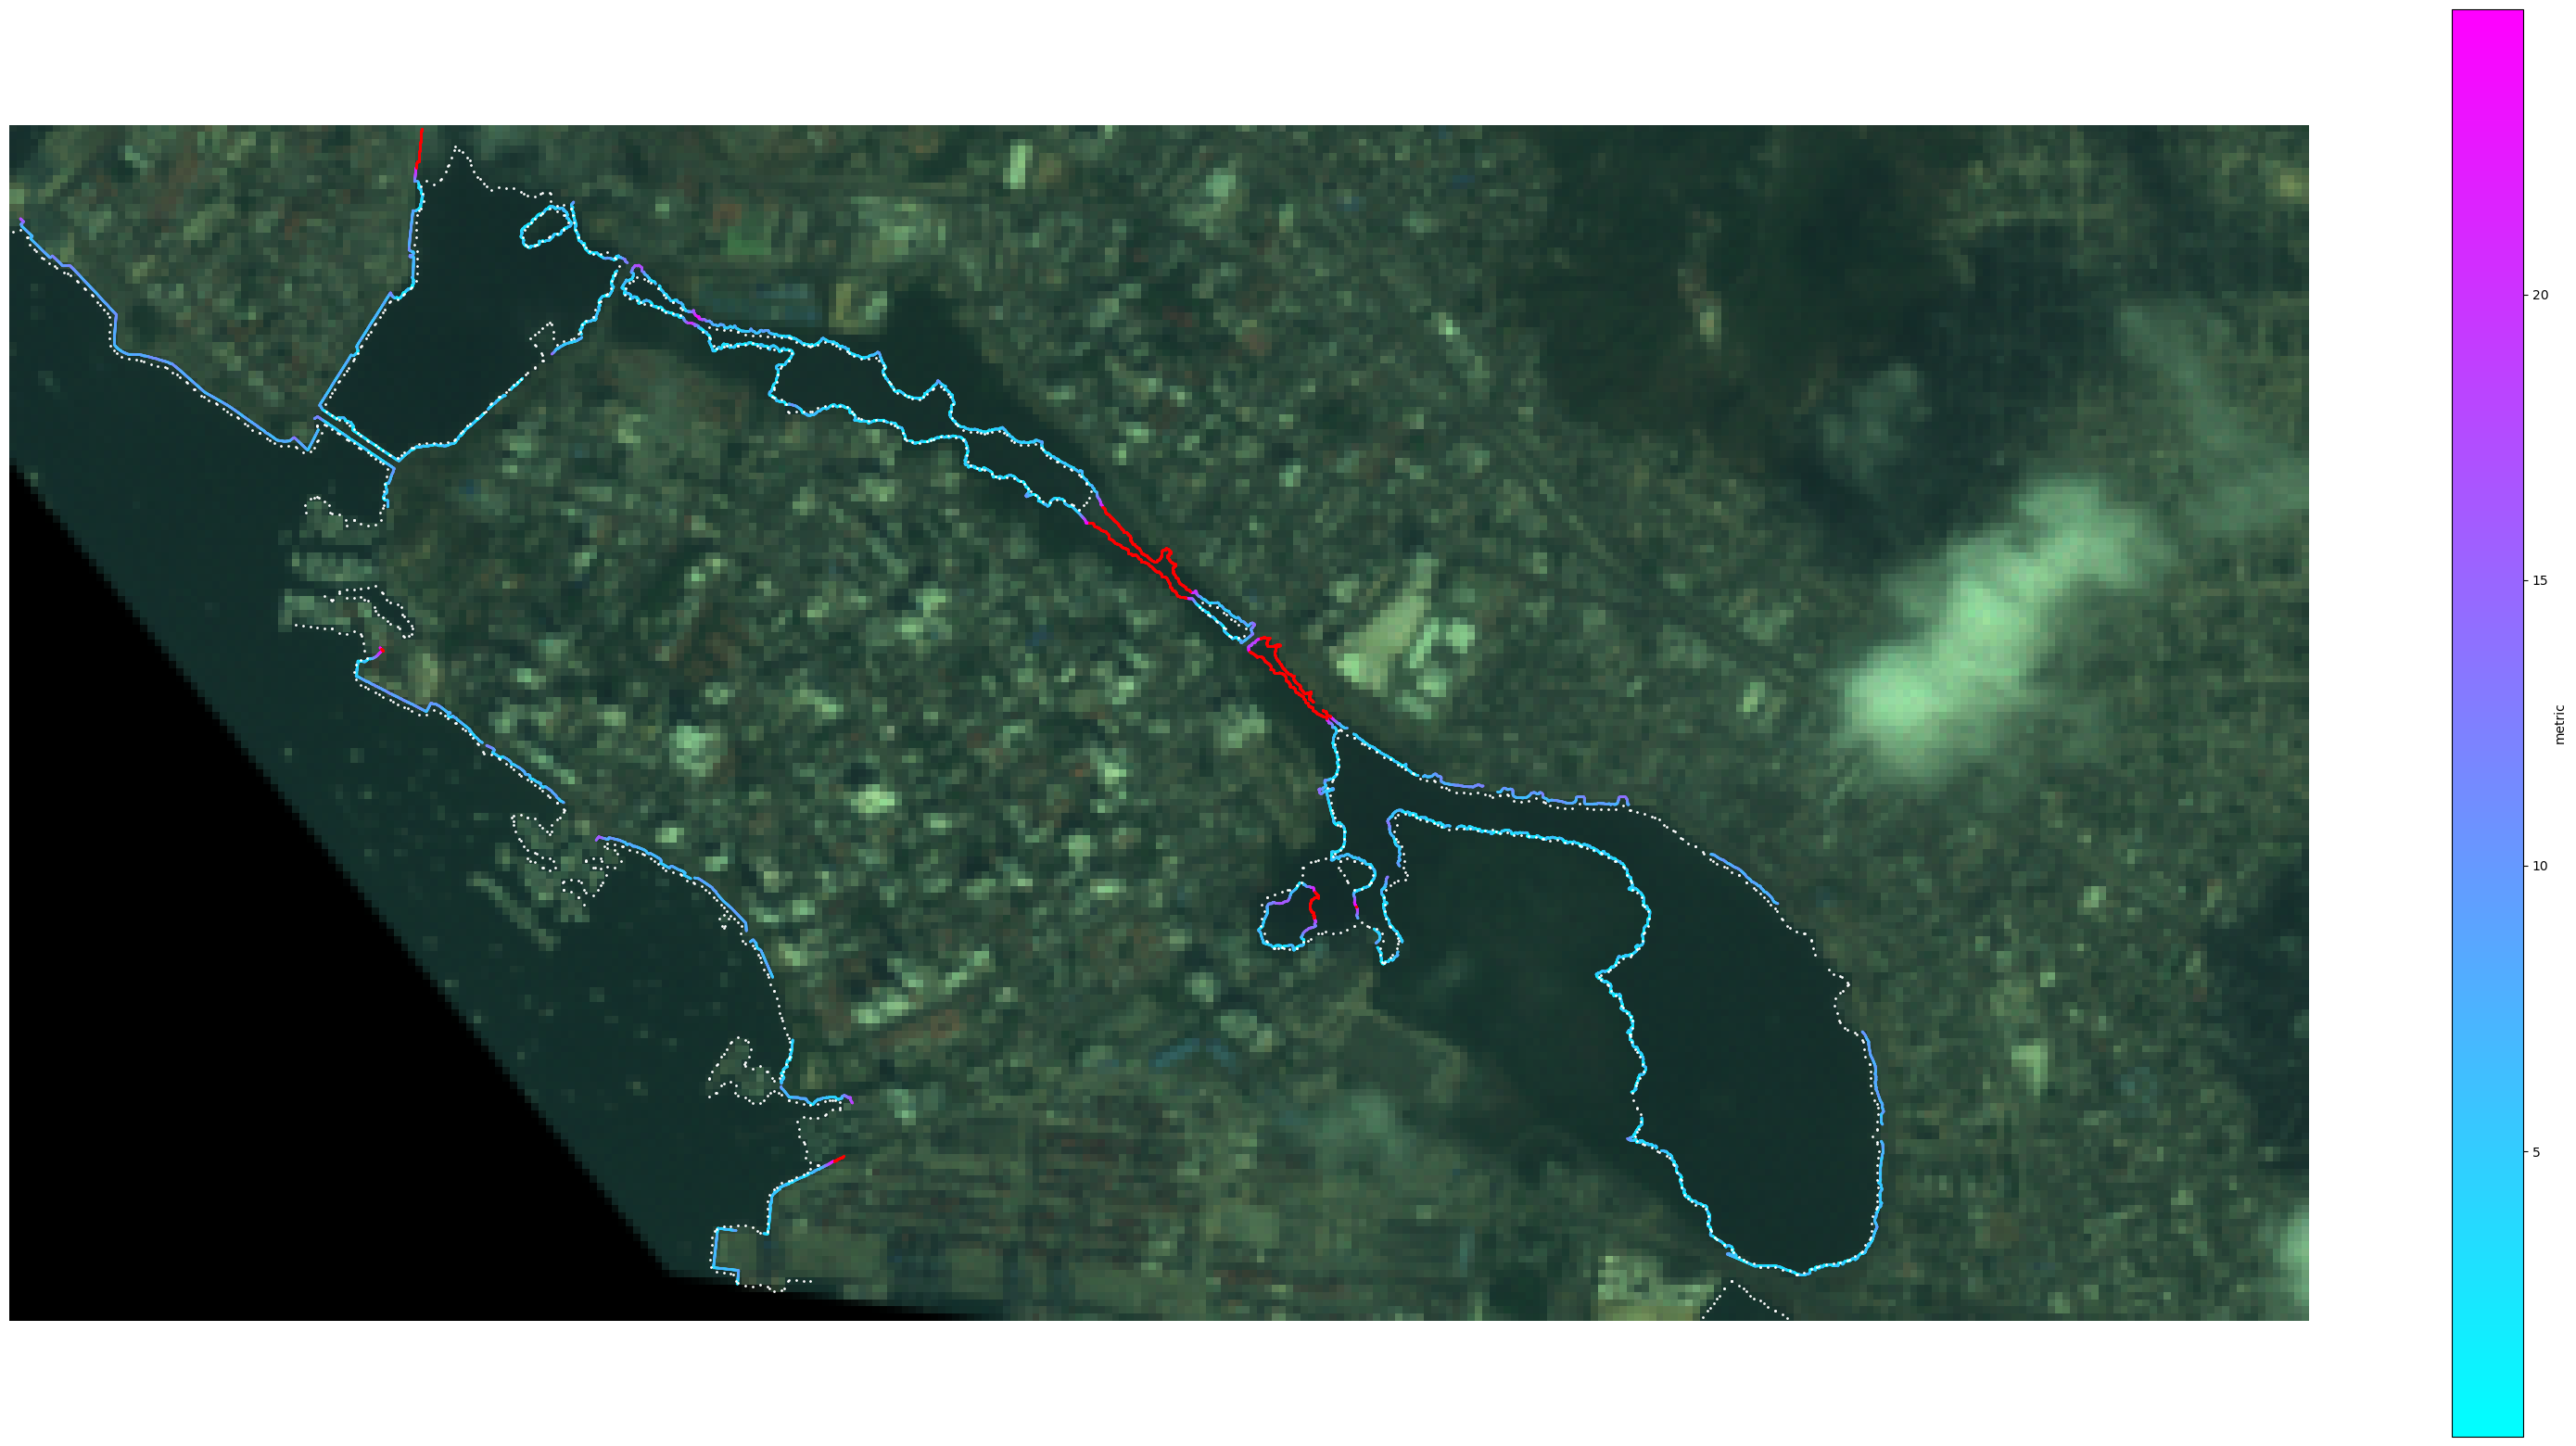

In [8]:
# tct_wetness + local_min_otsu (often has the best score for a sl point/transect, despite not having top overall metrics)
index = tct_wetness(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = local_min_otsu(index, cloud_mask, sl_buffer)

contours = wv_eval.get_contours(index.reshape(sim_bands.shape[:-1]), threshold, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

contour_pxl = SDS_tools.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, im_rgb, contours_pxl=contour_pxl)

print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")